In [1]:
import warnings
warnings.filterwarnings("ignore")

# Linear Discriminant Analysis (LDA) & the Bayes Optimal Classifier

## Big Picture
- Goal: find the **Bayes optimal classifier**, which needs the **conditional class probabilities** $P(Y=k \mid X=x)$.
- Curse of Dimensionality → we can't estimate these non-parametrically → we assume a **parametric model**.
- Two parametric routes:

| | Logistic Regression | LDA |
|---|---|---|
| Generative story | pick $x$ first, then label $y \mid x$ | pick label $k$ first, then $x \mid k$ |
| Models directly | $P(Y=k \mid x)$ (sigmoids) | $P(X=x \mid Y=k)$ and priors $\pi_k$ |
| Gets $P(Y=k \mid x)$ via | the model itself | **Bayes' theorem** |

**Connection:** parametric assumption → conditional class probabilities → Bayes optimal classifier

---

## The LDA Generative Process
1. Pick a class $k$ with **prior probability** $\pi_k = P(Y=k)$, where $\sum_{k=1}^K \pi_k = 1$.
2. Generate the input from that class's Gaussian:
$$X \mid Y=k \;\sim\; \mathcal{N}(\mu_k, \Sigma) \qquad \text{density denoted } f_k(x)$$

> ⚠️ **Note:** $P(X \mid Y=k)$ is the *reverse* of the conditional class probability $P(Y=k \mid X)$. Don't confuse them.

> ⚠️ **Correction to the lecture:** it writes a covariance $\Sigma_k$ per class. Standard **LDA assumes one shared $\Sigma$** for all classes (this is what makes the boundary *linear*). Class-specific $\Sigma_k$ gives **QDA** (quadratic boundary).

---

## Bayes' Theorem → Conditional Class Probabilities
$$P(Y=k \mid X=x) = \frac{\pi_k \, f_k(x)}{\sum_{l=1}^K \pi_l \, f_l(x)}$$

**Intuition:** posterior = (prior belief × how well $x$ fits class $k$) ÷ (total over all classes)

*(Should memorize.)*

---

## Bayes Optimal Classifier Under LDA
$$\hat{y}(x) = \arg\max_k P(Y=k \mid x) = \arg\max_k \; \pi_k \, f_k(x)$$

- The denominator is the **same for every class** (it only depends on $x$), so it doesn't change which $k$ wins.
- Dividing by a positive constant never changes the argmax. Example: $(5,7,3)$ and $(5/15, 7/15, 3/15)$ both peak at index 2.
- **Rule: pick the class with the tallest weighted Gaussian $\pi_k f_k(x)$.** *(Should memorize.)*

---

## Effect of the Priors (Binary, 1-D Example)
Setup: $\mu_1=-1.5$, $\mu_2=1.5$, $\sigma^2=1$.

| Priors | Threshold | Classifier |
|---|---|---|
| $\pi_1=\pi_2=0.5$ | $\gamma = 0$ | class 1 if $x<0$, else class 2 |
| $\pi_1=0.3,\ \pi_2=0.7$ | $\gamma < 0$ | class 1 if $x<\gamma$, else class 2 |

**Why does the threshold move left?** Class 2 is now more common a priori, so its weighted Gaussian is taller and "claims" more of the axis. The boundary shifts **toward the rarer class** (class 1).

**Threshold formula (equal variances)** *(understand, don't memorize; derived by setting $\pi_1 f_1(\gamma)=\pi_2 f_2(\gamma)$):*
$$\gamma = \underbrace{\frac{\mu_1+\mu_2}{2}}_{\text{midpoint}} + \underbrace{\frac{\sigma^2}{\mu_2-\mu_1}\ln\frac{\pi_1}{\pi_2}}_{\text{prior shift}}$$

Here: $\gamma = 0 + \frac{1}{3}\ln\frac{0.3}{0.7} \approx -0.28$.

---

## Key Takeaways
1. LDA is **generative**: pick class $k$ (prior $\pi_k$) → draw $x \sim \mathcal{N}(\mu_k, \Sigma)$. Logistic regression goes the other direction.
2. Bayes' theorem converts $f_k(x)$ and $\pi_k$ into the conditional class probability $P(Y=k \mid x)$.
3. Bayes optimal rule under LDA: $\arg\max_k \pi_k f_k(x)$. The denominator can be ignored.
4. With equal priors and equal variances, the boundary is the **midpoint** of the means.
5. **Priors matter:** unequal priors shift the boundary toward the rarer class.
6. Standard LDA = shared covariance → linear boundary; class-specific covariances = QDA.

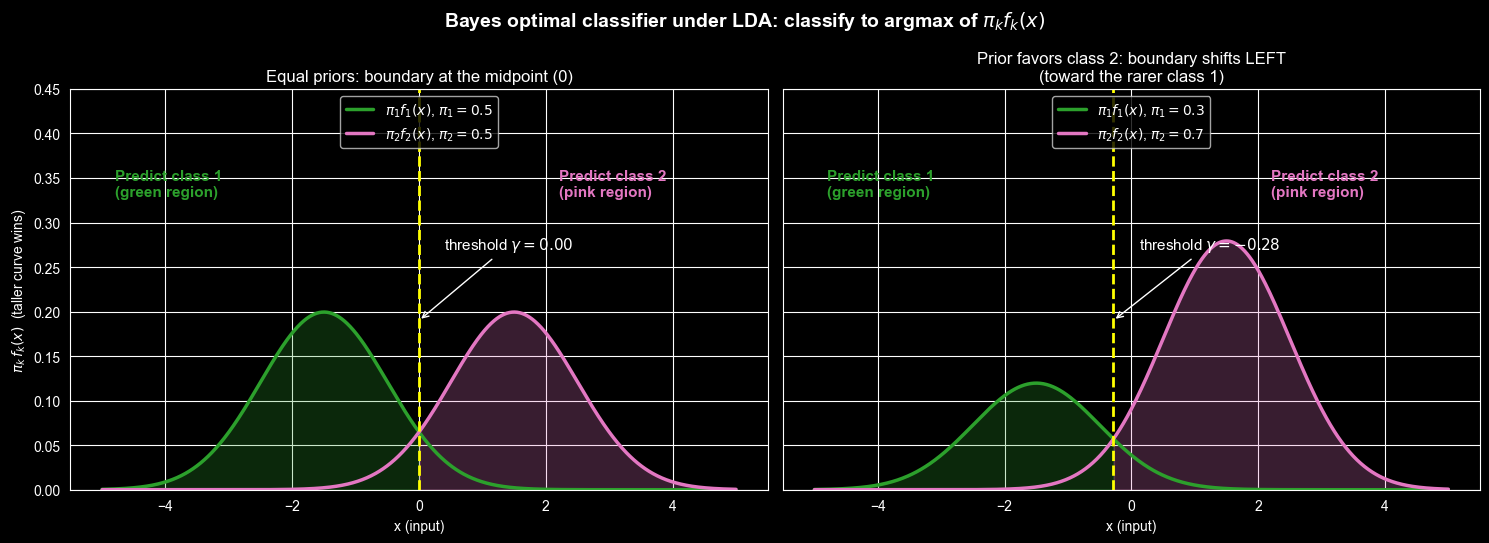

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Setup from lecture: two classes, equal variance
mu1, mu2, sigma = -1.5, 1.5, 1.0
x = np.linspace(-5, 5, 1000)

def threshold(pi1):
    """Boundary where pi1*f1(x) = pi2*f2(x) (equal variances)."""
    pi2 = 1 - pi1
    return (mu1 + mu2) / 2 + sigma**2 * np.log(pi1 / pi2) / (mu2 - mu1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, pi1 in zip(axes, [0.5, 0.3]):
    pi2 = 1 - pi1
    g1 = pi1 * norm.pdf(x, mu1, sigma)   # pi_1 * f_1(x)
    g2 = pi2 * norm.pdf(x, mu2, sigma)   # pi_2 * f_2(x)
    gamma = threshold(pi1)

    ax.plot(x, g1, color="tab:green", lw=2.5, label=rf"$\pi_1 f_1(x)$, $\pi_1={pi1}$")
    ax.plot(x, g2, color="tab:pink", lw=2.5, label=rf"$\pi_2 f_2(x)$, $\pi_2={pi2}$")

    # Shade the region each class "wins" (Bayes optimal rule = taller curve wins)
    ax.fill_between(x, 0, g1, where=x < gamma, color="tab:green", alpha=0.25)
    ax.fill_between(x, 0, g2, where=x >= gamma, color="tab:pink", alpha=0.25)

    ax.axvline(gamma, color="yellow", ls="--", lw=2)
    ax.annotate(rf"threshold $\gamma = {gamma:.2f}$",
                xy=(gamma, 0.19), xytext=(gamma + 0.4, 0.27),
                arrowprops=dict(arrowstyle="->"), fontsize=11)
    ax.text(-4.8, 0.33, "Predict class 1\n(green region)", color="tab:green", fontsize=11, weight="bold")
    ax.text(2.2, 0.33, "Predict class 2\n(pink region)", color="tab:pink", fontsize=11, weight="bold")

    ax.set_title("Equal priors: boundary at the midpoint (0)" if pi1 == 0.5
                 else "Prior favors class 2: boundary shifts LEFT\n(toward the rarer class 1)", fontsize=12)
    ax.set_xlabel("x (input)")
    ax.set_ylim(0, 0.45)
    ax.legend(loc="upper center", fontsize=10)

axes[0].set_ylabel(r"$\pi_k \, f_k(x)$  (taller curve wins)")
fig.suptitle("Bayes optimal classifier under LDA: classify to argmax of $\\pi_k f_k(x)$", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

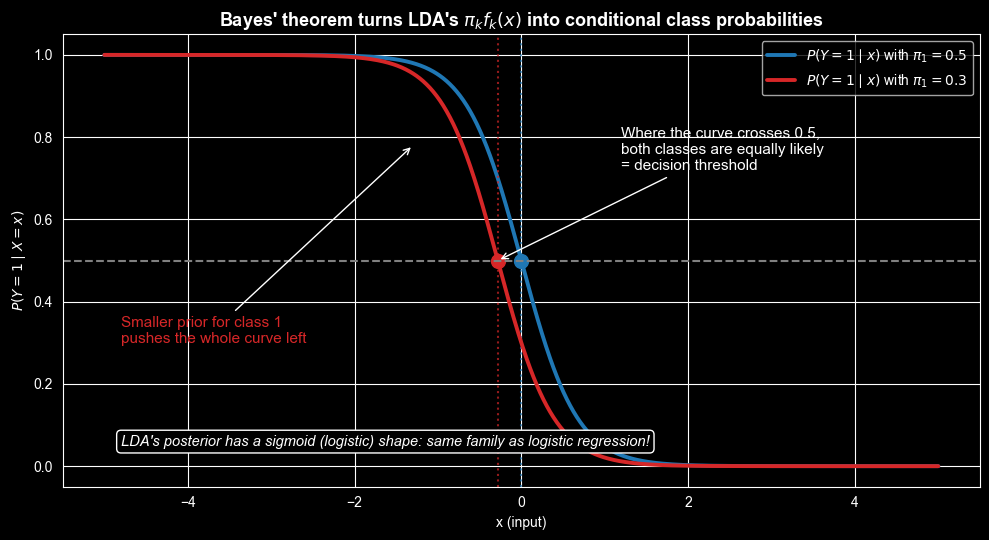

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu1, mu2, sigma = -1.5, 1.5, 1.0
x = np.linspace(-5, 5, 1000)

def posterior_class1(x, pi1):
    """Bayes' theorem: P(Y=1|x) = pi1*f1 / (pi1*f1 + pi2*f2)."""
    num = pi1 * norm.pdf(x, mu1, sigma)
    den = num + (1 - pi1) * norm.pdf(x, mu2, sigma)
    return num / den

fig, ax = plt.subplots(figsize=(10, 5.5))

for pi1, color in [(0.5, "tab:blue"), (0.3, "tab:red")]:
    ax.plot(x, posterior_class1(x, pi1), color=color, lw=2.8,
            label=rf"$P(Y=1\mid x)$ with $\pi_1={pi1}$")
    # Where posterior crosses 0.5 is exactly the Bayes decision threshold
    gamma = (mu1 + mu2) / 2 + sigma**2 * np.log(pi1 / (1 - pi1)) / (mu2 - mu1)
    ax.plot(gamma, 0.5, "o", color=color, ms=10)
    ax.axvline(gamma, color=color, ls=":", alpha=0.7)

ax.axhline(0.5, color="gray", ls="--")
ax.annotate("Where the curve crosses 0.5,\nboth classes are equally likely\n= decision threshold",
            xy=(-0.28, 0.5), xytext=(1.2, 0.72), arrowprops=dict(arrowstyle="->"), fontsize=11)
ax.annotate("Smaller prior for class 1\npushes the whole curve left",
            xy=(-1.3, 0.78), xytext=(-4.8, 0.3), arrowprops=dict(arrowstyle="->"), fontsize=11, color="tab:red")
ax.text(-4.8, 0.05, "LDA's posterior has a sigmoid (logistic) shape: same family as logistic regression!",
        fontsize=10.5, style="italic", bbox=dict(boxstyle="round", fc="black"))

ax.set_xlabel("x (input)")
ax.set_ylabel(r"$P(Y=1 \mid X=x)$")
ax.set_title("Bayes' theorem turns LDA's $\\pi_k f_k(x)$ into conditional class probabilities", fontsize=13, weight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

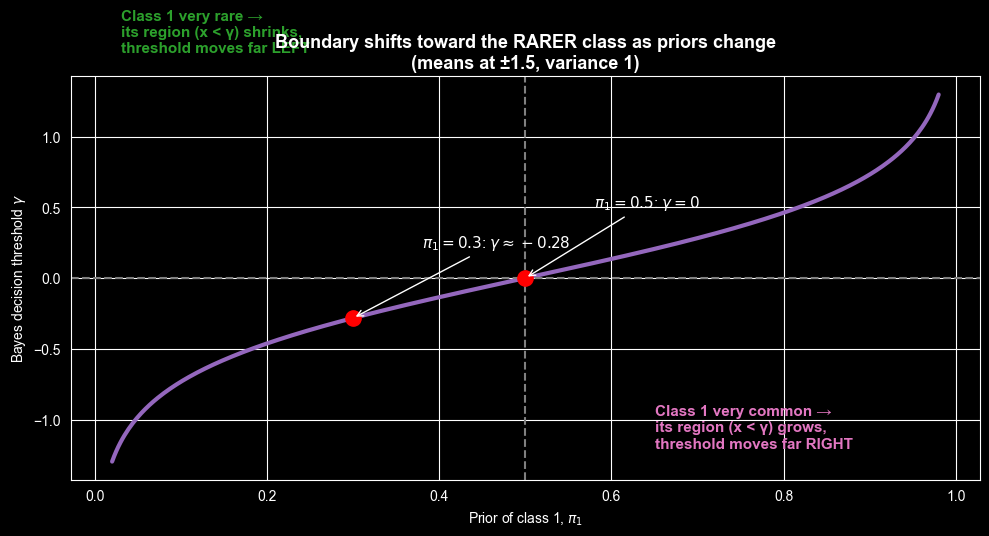

In [5]:
import numpy as np
import matplotlib.pyplot as plt

mu1, mu2, sigma = -1.5, 1.5, 1.0
pi1_vals = np.linspace(0.02, 0.98, 400)
gammas = (mu1 + mu2) / 2 + sigma**2 * np.log(pi1_vals / (1 - pi1_vals)) / (mu2 - mu1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(pi1_vals, gammas, lw=3, color="tab:purple")
ax.axhline(0, color="gray", ls="--")
ax.axvline(0.5, color="gray", ls="--")

# Lecture's two cases
for pi1, label in [(0.5, r"$\pi_1=0.5$: $\gamma=0$"), (0.3, r"$\pi_1=0.3$: $\gamma\approx-0.28$")]:
    g = (mu1 + mu2) / 2 + sigma**2 * np.log(pi1 / (1 - pi1)) / (mu2 - mu1)
    ax.plot(pi1, g, "o", ms=11, color="red")
    ax.annotate(label, xy=(pi1, g), xytext=(pi1 + 0.08, g + 0.5),
                arrowprops=dict(arrowstyle="->"), fontsize=11)

ax.text(0.04, 1.6, "Class 1 is rare:\nboundary moves RIGHT (toward class 2... wait: class 1 rarely wins,\nso its region shrinks)",
        fontsize=0.1, alpha=0)  # placeholder removed below
ax.text(0.03, 1.9, "Class 1 very rare →\nits region (x < γ) shrinks,\nthreshold moves far LEFT", fontsize=11,
        color="tab:green", weight="bold", va="top")
ax.text(0.65, -1.2, "Class 1 very common →\nits region (x < γ) grows,\nthreshold moves far RIGHT", fontsize=11,
        color="tab:pink", weight="bold")

ax.set_xlabel(r"Prior of class 1, $\pi_1$")
ax.set_ylabel(r"Bayes decision threshold $\gamma$")
ax.set_title("Boundary shifts toward the RARER class as priors change\n(means at ±1.5, variance 1)", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# LDA Part 2: Linear Discriminants, Parameter Estimation & Multivariate LDA

**Connection:** LDA generative model → Bayes' theorem → $\arg\max_k \pi_k f_k(x)$ → **linear discriminant $\delta_k(x)$** → estimate parameters from data → plug-in classifier

---

## 1. From $\pi_k f_k(x)$ to a Linear Function (1-D, shared variance)

Univariate Gaussian density:
$$f_k(x) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\left(-\frac{(x-\mu_k)^2}{2\sigma^2}\right)$$

Bayes optimal rule: $\hat{y}(x)=\arg\max_k \pi_k f_k(x)$.

**Log trick:** $\log$ is monotonically increasing, so maximizing $\log(\cdot)$ gives the same winner (same idea as $5,7,3$ vs $\log 5,\log 7,\log 3$).

$$\log\big(\pi_k f_k(x)\big) = \log \pi_k - \frac{(x-\mu_k)^2}{2\sigma^2} - \log(\sqrt{2\pi}\sigma)$$

Expanding $(x-\mu_k)^2$ and dropping every term that **doesn't depend on $k$** ($-\frac{x^2}{2\sigma^2}$ and $-\log(\sqrt{2\pi}\sigma)$ are shared by all classes):

$$\boxed{\delta_k(x) = x\,\frac{\mu_k}{\sigma^2} - \frac{\mu_k^2}{2\sigma^2} + \log \pi_k} \qquad \hat{y}(x)=\arg\max_k \delta_k(x)$$

*(Should memorize.)*

**Intuition:** each class gets a **straight line** in $x$ (slope $\mu_k/\sigma^2$, intercept $-\frac{\mu_k^2}{2\sigma^2}+\log\pi_k$). Classify to whichever line is highest at $x$. This is why it's *Linear* Discriminant Analysis, and it's cheap to compute.

> The quadratic term $x^2$ cancels **only because the variance is shared**. With different $\sigma_k^2$ it doesn't cancel → QDA (curved boundary).

---

## 2. Estimating Parameters from Data

In reality nature is a **black box**: we only see a data set $D$ and don't know $\pi_k,\mu_k,\sigma^2$. So we **plug in estimates** (*should memorize*, they are all just averages):

| Parameter | Estimate | Plain English |
|---|---|---|
| Prior $\pi_k$ | $\hat{\pi}_k = \dfrac{N_k}{N}$ | fraction of samples in class $k$ |
| Mean $\mu_k$ | $\hat{\mu}_k = \dfrac{1}{N_k}\displaystyle\sum_{i:\,y_i=k} x_i$ | average of class-$k$ points |
| Shared variance $\sigma^2$ | $\hat{\sigma}^2 = \dfrac{1}{N-K}\displaystyle\sum_{k=1}^{K}\sum_{i:\,y_i=k}(x_i-\hat{\mu}_k)^2$ | **pooled** spread around each class's own mean |

Here $N=\sum_k N_k$ and $K$ = number of classes. The pooled variance is also a weighted average of per-class variances: $\hat\sigma^2=\sum_k \frac{N_k-1}{N-K}\,\hat\sigma_k^2$.

Then plug into $\delta_k$ → **estimated** classifier.

**Key idea:** the estimated threshold $\hat\gamma$ is a *random quantity*. It will be close to, but not exactly, the true Bayes threshold.
- Example: true threshold is $0$ (equal priors, means $\pm1.5$, $\sigma^2=1$); our sample gives some $\hat\gamma\neq 0$.
- ⚠️ The lecture's example had $\hat\gamma$ slightly *below* 0, but that's just that sample. A different sample could land above 0. There's no systematic direction.

---

## 3. Multivariate LDA ($p>1$)

$$X \mid Y=k \;\sim\; \mathcal{N}_p(\mu_k, \Sigma), \qquad \mu_k\in\mathbb{R}^p,\ \Sigma\in\mathbb{R}^{p\times p}\ \text{(shared)}$$

Discriminant function (direct generalization of the 1-D case):
$$\delta_k(\mathbf{x}) = \mathbf{x}^T\Sigma^{-1}\mu_k - \tfrac12\mu_k^T\Sigma^{-1}\mu_k + \log\pi_k$$

*(Understand the structure: linear in $\mathbf{x}$; the formula itself is the 1-D one with $\sigma^2\to\Sigma$.)*

- **Level sets** of a Gaussian = **ellipses** (slice the bell horizontally, look from above). Center = $\mu_k$; shape = $\Sigma$.
- Because $\Sigma$ is shared, all ellipses have the same shape/orientation, and **decision boundaries between classes are straight lines** (hyperplanes in higher dimensions).
- With $K$ classes, the plane is carved into $K$ regions meeting along straight edges.

> ⚠️ **Lecture slip:** it says "in practice, we *would have access* to the means, covariance, and priors." It should be "we would **not** have access", we must **estimate** them from data (same as the 1-D case), giving boundaries slightly different from the theoretical ones.
> ⚠️ Notation: the lecture sometimes writes $\Sigma_k$ even though it assumes a shared $\Sigma$. In standard LDA there is no subscript.

---

## Key Takeaways
1. Taking $\log$ of $\pi_k f_k(x)$ doesn't change the argmax and, with a **shared variance**, yields **linear** discriminants $\delta_k(x)$.
2. Classify by picking the class with the **largest $\delta_k(x)$**.
3. Parameters are unknown, so estimate: $\hat\pi_k=N_k/N$, $\hat\mu_k$ = class average, $\hat\sigma^2$ = **pooled** within-class variance.
4. The fitted classifier's threshold is a **random estimate** of the true Bayes threshold, and it varies from sample to sample.
5. Multivariate LDA: shared $\Sigma$ → elliptical level sets with identical shape → **linear boundaries**.
6. We never know nature's parameters; LDA = *assume Gaussians + estimate + plug in*.

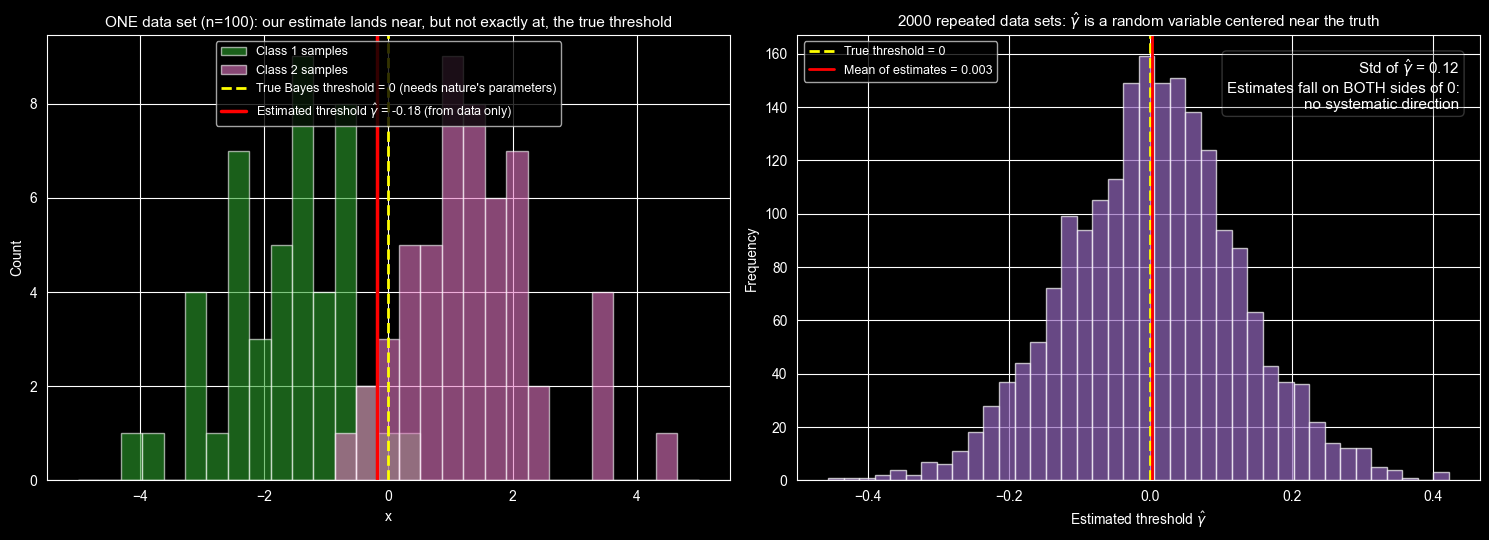

In [27]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
mu1_true, mu2_true, sigma_true = -1.5, 1.5, 1.0   # nature's (hidden) parameters; true threshold = 0

def fit_lda_1d(n):
    """Sample a data set of size n, then ESTIMATE pi, mu, pooled variance and the threshold."""
    is_class1 = rng.random(n) < 0.5                                  # true priors = 0.5
    x = np.where(is_class1, rng.normal(mu1_true, sigma_true, n),
                            rng.normal(mu2_true, sigma_true, n))
    x1, x2 = x[is_class1], x[~is_class1]
    pi1_hat, pi2_hat = len(x1) / n, len(x2) / n                      # N_k / N
    mu1_hat, mu2_hat = x1.mean(), x2.mean()                          # class averages
    var_hat = (((x1 - mu1_hat)**2).sum() + ((x2 - mu2_hat)**2).sum()) / (n - 2)   # pooled, N-K
    gamma_hat = (mu1_hat + mu2_hat)/2 + var_hat*np.log(pi1_hat/pi2_hat)/(mu2_hat - mu1_hat)
    return x1, x2, gamma_hat

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# LEFT: one data set, true vs estimated threshold
x1, x2, gamma_hat = fit_lda_1d(100)
bins = np.linspace(-5, 5, 30)
axes[0].hist(x1, bins, color="tab:green", alpha=0.6, label="Class 1 samples")
axes[0].hist(x2, bins, color="tab:pink", alpha=0.6, label="Class 2 samples")
axes[0].axvline(0, color="yellow", ls="--", lw=2, label="True Bayes threshold = 0 (needs nature's parameters)")
axes[0].axvline(gamma_hat, color="red", lw=2.5, label=rf"Estimated threshold $\hat\gamma$ = {gamma_hat:.2f} (from data only)")
axes[0].set_title("ONE data set (n=100): our estimate lands near, but not exactly at, the true threshold", fontsize=11)
axes[0].set_xlabel("x"); axes[0].set_ylabel("Count"); axes[0].legend(fontsize=9, loc="upper center")

# RIGHT: repeat the whole experiment many times
gammas = np.array([fit_lda_1d(100)[2] for _ in range(2000)])
axes[1].hist(gammas, bins=40, color="tab:purple", alpha=0.7)
axes[1].axvline(0, color="yellow", ls="--", lw=2, label="True threshold = 0")
axes[1].axvline(gammas.mean(), color="red", lw=2, label=f"Mean of estimates = {gammas.mean():.3f}")
axes[1].text(0.97, 0.95, f"Std of $\\hat\\gamma$ = {gammas.std():.2f}\nEstimates fall on BOTH sides of 0:\nno systematic direction",
             transform=axes[1].transAxes, ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round", fc="black", alpha=0.2))
axes[1].set_title("2000 repeated data sets: $\\hat\\gamma$ is a random variable centered near the truth", fontsize=11)
axes[1].set_xlabel(r"Estimated threshold $\hat\gamma$"); axes[1].set_ylabel("Frequency"); axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout(); plt.show()

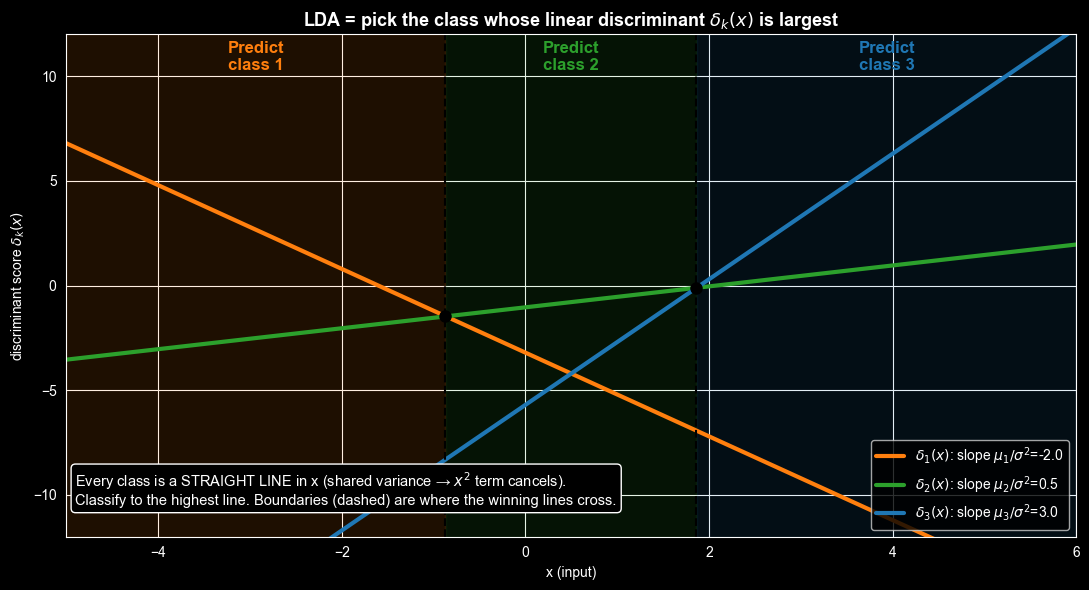

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Three classes in 1-D, shared variance
mus = np.array([-2.0, 0.5, 3.0]); pis = np.array([0.3, 0.4, 0.3]); sigma2 = 1.0
colors = ["tab:orange", "tab:green", "tab:blue"]
x = np.linspace(-5, 6, 1000)

# delta_k(x) = x*mu_k/sigma^2 - mu_k^2/(2 sigma^2) + log(pi_k)  -> a straight line in x
deltas = np.array([x*m/sigma2 - m**2/(2*sigma2) + np.log(p) for m, p in zip(mus, pis)])
winner = deltas.argmax(axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
ymin, ymax = -12, 12
for k in range(3):
    ax.plot(x, deltas[k], color=colors[k], lw=3,
            label=rf"$\delta_{k+1}(x)$: slope $\mu_{k+1}/\sigma^2$={mus[k]/sigma2:.1f}")
    ax.fill_between(x, ymin, ymax, where=(winner == k), color=colors[k], alpha=0.12)   # region where class k wins
    ax.text(np.median(x[winner == k]), 10.3, f"Predict\nclass {k+1}", color=colors[k], ha="center", fontsize=12, weight="bold")

# Decision boundary = where the top two lines cross
changes = np.where(np.diff(winner) != 0)[0]
for c in changes:
    ax.axvline(x[c], color="black", ls="--"); ax.plot(x[c], deltas[winner[c], c], "ko", ms=8)

ax.text(-4.9, -10.5, "Every class is a STRAIGHT LINE in x (shared variance → $x^2$ term cancels).\n"
        "Classify to the highest line. Boundaries (dashed) are where the winning lines cross.",
        fontsize=10.5, bbox=dict(boxstyle="round", fc="black"))
ax.set_ylim(ymin, ymax); ax.set_xlim(-5, 6)
ax.set_xlabel("x (input)"); ax.set_ylabel(r"discriminant score $\delta_k(x)$")
ax.set_title("LDA = pick the class whose linear discriminant $\\delta_k(x)$ is largest", fontsize=13, weight="bold")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

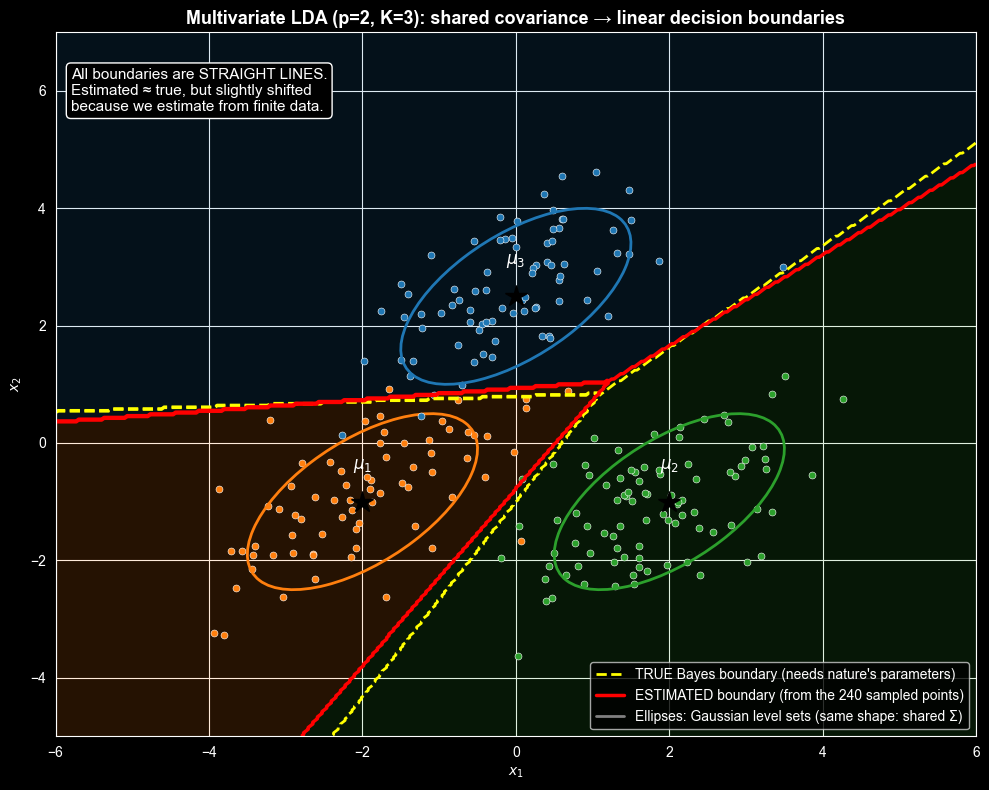

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

rng = np.random.default_rng(3)
colors = ["tab:orange", "tab:green", "tab:blue"]

# Nature's hidden parameters: 3 classes, 2-D inputs, SHARED covariance
mus = np.array([[-2.0, -1.0], [2.0, -1.0], [0.0, 2.5]])
Sigma = np.array([[1.0, 0.6], [0.6, 1.0]])
pis = np.array([1/3, 1/3, 1/3])
K, N = 3, 240

# Sample a data set D
y = rng.choice(K, size=N, p=pis)
X = mus[y] + rng.multivariate_normal([0, 0], Sigma, size=N)

# ESTIMATE parameters from D: priors, means, pooled covariance
pis_hat = np.array([(y == k).mean() for k in range(K)])
mus_hat = np.array([X[y == k].mean(axis=0) for k in range(K)])
resid = X - mus_hat[y]
Sigma_hat = resid.T @ resid / (N - K)          # pooled covariance, divide by N-K

def delta(points, mus, Sigma, pis):
    """delta_k(x) = x^T S^-1 mu_k - 0.5 mu_k^T S^-1 mu_k + log pi_k  (all classes at once)."""
    Sinv = np.linalg.inv(Sigma)
    return points @ Sinv @ mus.T - 0.5*np.sum((mus @ Sinv) * mus, axis=1) + np.log(pis)

# Classify every point of a grid under TRUE and ESTIMATED parameters
xx, yy = np.meshgrid(np.linspace(-6, 6, 400), np.linspace(-5, 7, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
pred_true = delta(grid, mus, Sigma, pis).argmax(axis=1).reshape(xx.shape)
pred_hat = delta(grid, mus_hat, Sigma_hat, pis_hat).argmax(axis=1).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, pred_hat, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors, alpha=0.15)  # estimated regions
ax.contour(xx, yy, pred_true, levels=[0.5, 1.5], colors="yellow", linestyles="--", linewidths=2)  # true boundary
ax.contour(xx, yy, pred_hat, levels=[0.5, 1.5], colors="red", linewidths=2.5)                    # estimated boundary

for k in range(K):
    ax.scatter(*X[y == k].T, color=colors[k], s=25, edgecolor="white", linewidth=0.4)
    ax.plot(*mus[k], "k*", ms=16)
    ax.text(mus[k][0], mus[k][1] + 0.55, rf"$\mu_{k+1}$", ha="center", weight="bold", fontsize=12)
    # Level-set ellipse of the true Gaussian (same shape for every class because Sigma is shared)
    vals, vecs = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax.add_patch(Ellipse(mus[k], 2*1.5*np.sqrt(vals[1]), 2*1.5*np.sqrt(vals[0]), angle=angle,
                         fill=False, edgecolor=colors[k], lw=2))

ax.legend(handles=[Line2D([0], [0], color="yellow", ls="--", lw=2, label="TRUE Bayes boundary (needs nature's parameters)"),
                   Line2D([0], [0], color="red", lw=2.5, label="ESTIMATED boundary (from the 240 sampled points)"),
                   Line2D([0], [0], color="gray", lw=2, label="Ellipses: Gaussian level sets (same shape: shared Σ)")],
          loc="lower right", fontsize=10)
ax.text(-5.8, 6.4, "All boundaries are STRAIGHT LINES.\nEstimated ≈ true, but slightly shifted\nbecause we estimate from finite data.",
        fontsize=11, bbox=dict(boxstyle="round", fc="black"), va="top")
ax.set_xlim(-6, 6); ax.set_ylim(-5, 7)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title("Multivariate LDA (p=2, K=3): shared covariance → linear decision boundaries", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

# Classification Errors (Binary) & Setup for LDA's Expected Error

**Connection:** LDA → Bayes optimal classifier (threshold $\gamma$) → **how often is it wrong, and in which direction?**

---

## 1. The Four Outcomes
Binary problem: labels $y_i\in\{0,1\}$, classifier $C(\mathbf{x}_i)\in\{0,1\}$. Call label **1 = "positive"**.

| | Actual $y_i=1$ | Actual $y_i=0$ |
|---|---|---|
| **Predict $C=1$** | ✅ True Positive (TP) | ❌ **False Positive (FP)** |
| **Predict $C=0$** | ❌ **False Negative (FN)** | ✅ True Negative (TN) |

- **FP** = "false alarm": we say positive, truth is negative.
- **FN** = "miss": we say negative, truth is positive.
- **Example (biopsy):** FP = healthy tissue called cancerous; FN = cancer that gets missed.
- **The two mistakes usually have different costs** (a missed cancer is far worse than a false alarm), so we should look at them *separately*, not only at the total.

---

## 2. Counting Errors with Indicator Functions
$$\#\text{FP}=\sum_{i=1}^{N}\delta\big(C(\mathbf{x}_i)-1\big)\,\delta(y_i) \qquad\quad \#\text{FN}=\sum_{i=1}^{N}\delta\big(C(\mathbf{x}_i)\big)\,\delta(y_i-1)$$

- $\delta(a)=1$ if $a=0$, else $0$. The product is $1$ only if **both** conditions hold.
- FP: $C(\mathbf{x}_i)=1$ **and** $y_i=0$. FN: $C(\mathbf{x}_i)=0$ **and** $y_i=1$.
- Summing over all points just **counts** them.

> ⚠️ **Terminology fix:** the lecture calls $\delta$ the "Dirac delta". For discrete labels it's really the **Kronecker delta** (an indicator, "$1$ if equal, else $0$"). The Dirac delta is the continuous-variable cousin. Treat $\delta(a)$ here as simply $\mathbf{1}[a=0]$.

$$\boxed{\text{Error rate}=\frac{\#\text{FP}+\#\text{FN}}{N}} \quad\text{(should memorize)}$$

---

## 3. Expected Error of the LDA Bayes Classifier (setup)
Ingredients (1-D, i.e. $p=1$, two classes): priors $\pi_0,\pi_1$ and class densities $f_0(x),f_1(x)$.

**In practice** we compute error on a data set (a number). **In theory**, given the true ingredients, we can compute the **expected** error exactly.

Bayes optimal rule:
$$C(x)=\begin{cases}0 & \pi_0 f_0(x)>\pi_1 f_1(x)\;\;\Leftrightarrow\;\; x<\gamma\\[2pt] 1 & \pi_1 f_1(x)\ge\pi_0 f_0(x)\;\;\Leftrightarrow\;\; x\ge\gamma\end{cases}$$
$\gamma$ = crossing point of the weighted Gaussians.

> The "$x<\gamma\Rightarrow 0$" form assumes class 0 sits to the *left* of class 1 ($\mu_0<\mu_1$).

**Natural next step** (the standard result, not yet derived in this video): each error is a **tail area** of a weighted Gaussian
$$\text{FP}:\ \pi_0\,P(X\ge\gamma\mid Y=0) \qquad \text{FN}:\ \pi_1\,P(X<\gamma\mid Y=1)$$
$$\text{Expected error}=\text{FP}+\text{FN}$$

*Conceptual only; no need to memorize.*

---

## Key Takeaways
1. Four outcomes: TP, TN, **FP** (false alarm), **FN** (miss).
2. Total errors = FP + FN; error rate = (FP + FN) / N.
3. FP and FN usually have **different real-world costs**, so inspect both.
4. The product of two indicators ($\delta$'s) counts points satisfying both conditions.
5. The Bayes classifier under LDA is a threshold rule at $\gamma$, where $\pi_0 f_0=\pi_1 f_1$.
6. Its expected error is the **overlapping tail area** of the two weighted Gaussians.

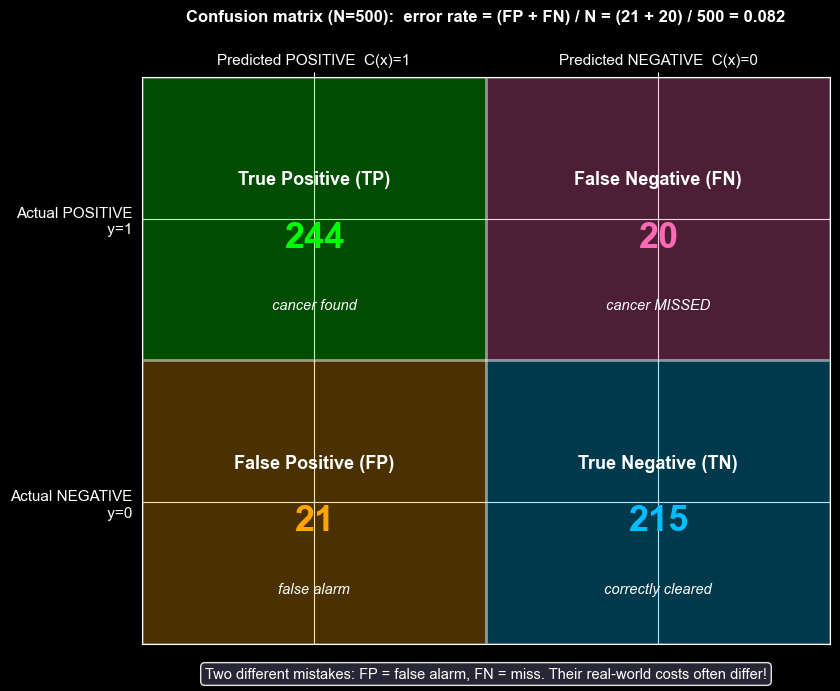

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.style.use("dark_background")
rng = np.random.default_rng(5)

# Simulate biopsies: y=1 cancerous, y=0 healthy; 1-D measurement x
n = 500
y = (rng.random(n) < 0.5).astype(int)
x = rng.normal(np.where(y == 1, 1.5, -1.5), 1.0)
C = (x >= 0).astype(int)                       # Bayes classifier for equal priors: threshold gamma = 0

# Count outcomes with the indicator logic: (condition 1) AND (condition 2)
TP = np.sum((C == 1) & (y == 1)); FN = np.sum((C == 0) & (y == 1))
FP = np.sum((C == 1) & (y == 0)); TN = np.sum((C == 0) & (y == 0))

fig, ax = plt.subplots(figsize=(8.5, 7))
cells = {  # (row = actual, col = predicted)
    (0, 0): ("True Positive (TP)", TP, "lime", "cancer found"),
    (0, 1): ("False Negative (FN)", FN, "hotpink", "cancer MISSED"),
    (1, 0): ("False Positive (FP)", FP, "orange", "false alarm"),
    (1, 1): ("True Negative (TN)", TN, "deepskyblue", "correctly cleared"),
}
for (r, c), (name, count, col, desc) in cells.items():
    ax.add_patch(Rectangle((c, r), 1, 1, facecolor=col, alpha=0.3, edgecolor="white", lw=2))
    ax.text(c + 0.5, r + 0.38, name, ha="center", fontsize=13, weight="bold", color="white")
    ax.text(c + 0.5, r + 0.6, str(count), ha="center", fontsize=26, weight="bold", color=col)
    ax.text(c + 0.5, r + 0.82, desc, ha="center", fontsize=10.5, color="white", style="italic")

ax.set_xlim(0, 2); ax.set_ylim(2, 0)
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["Predicted POSITIVE  C(x)=1", "Predicted NEGATIVE  C(x)=0"], fontsize=11)
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["Actual POSITIVE\n y=1", "Actual NEGATIVE\n y=0"], fontsize=11)
ax.xaxis.tick_top()
err = (FP + FN) / n
ax.set_title(f"Confusion matrix (N={n}):  error rate = (FP + FN) / N = ({FP} + {FN}) / {n} = {err:.3f}",
             fontsize=12, weight="bold", pad=40)
ax.text(1, 2.12, "Two different mistakes: FP = false alarm, FN = miss. Their real-world costs often differ!",
        ha="center", fontsize=10.5, color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))
plt.tight_layout(); plt.show()

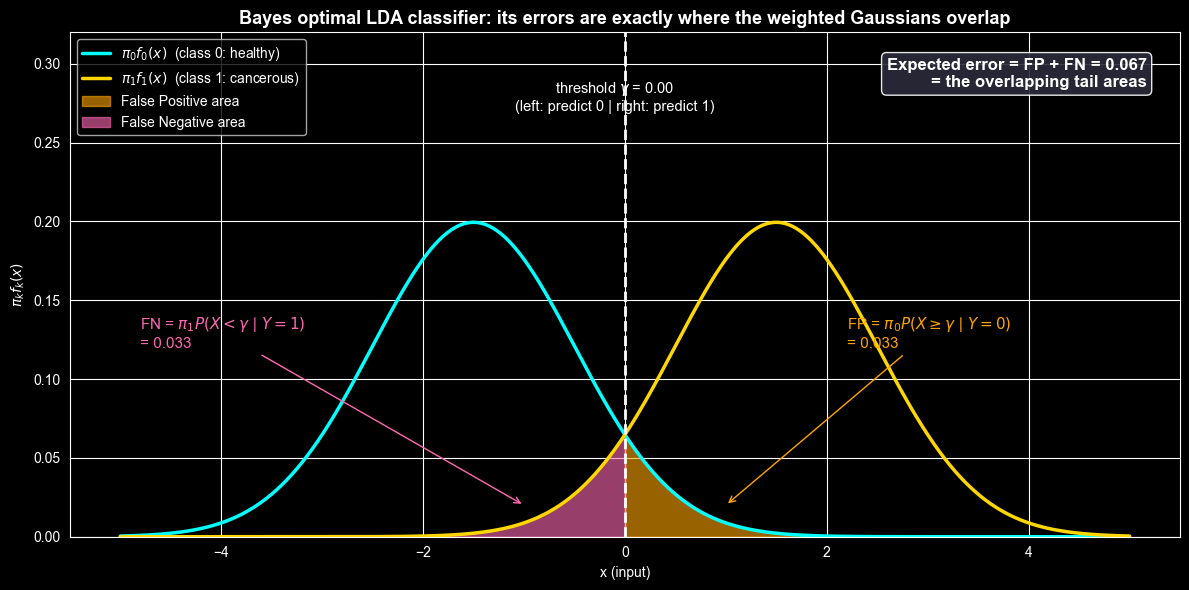

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

# Setup: class 0 (healthy) at -1.5, class 1 (cancerous) at +1.5, shared sigma, equal priors
mu0, mu1, sigma = -1.5, 1.5, 1.0
pi0, pi1 = 0.5, 0.5
gamma = (mu0 + mu1)/2 + sigma**2 * np.log(pi0/pi1)/(mu1 - mu0)    # crossing point of the weighted Gaussians

x = np.linspace(-5, 5, 1000)
g0 = pi0 * norm.pdf(x, mu0, sigma)       # pi_0 f_0(x)
g1 = pi1 * norm.pdf(x, mu1, sigma)       # pi_1 f_1(x)

# Error pieces = tail areas of the weighted Gaussians
fp = pi0 * norm.sf(gamma, mu0, sigma)    # pi_0 * P(X >= gamma | Y=0)
fn = pi1 * norm.cdf(gamma, mu1, sigma)   # pi_1 * P(X <  gamma | Y=1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, g0, color="cyan", lw=2.5, label=r"$\pi_0 f_0(x)$  (class 0: healthy)")
ax.plot(x, g1, color="gold", lw=2.5, label=r"$\pi_1 f_1(x)$  (class 1: cancerous)")
ax.fill_between(x, 0, g0, where=x >= gamma, color="orange", alpha=0.6, label="False Positive area")
ax.fill_between(x, 0, g1, where=x < gamma, color="hotpink", alpha=0.6, label="False Negative area")
ax.axvline(gamma, color="white", ls="--", lw=2)

ax.text(gamma - 0.1, 0.27, r"threshold $\gamma$" + f" = {gamma:.2f}\n(left: predict 0 | right: predict 1)",
        ha="center", fontsize=10.5, color="white")
ax.annotate(f"FP = " + r"$\pi_0 P(X\geq\gamma\mid Y=0)$" + f"\n= {fp:.3f}", xy=(1.0, 0.02), xytext=(2.2, 0.12),
            arrowprops=dict(arrowstyle="->", color="orange"), color="orange", fontsize=11)
ax.annotate(f"FN = " + r"$\pi_1 P(X<\gamma\mid Y=1)$" + f"\n= {fn:.3f}", xy=(-1.0, 0.02), xytext=(-4.8, 0.12),
            arrowprops=dict(arrowstyle="->", color="hotpink"), color="hotpink", fontsize=11)
ax.text(0.97, 0.95, f"Expected error = FP + FN = {fp+fn:.3f}\n= the overlapping tail areas",
        transform=ax.transAxes, ha="right", va="top", fontsize=12, weight="bold", color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

ax.set_xlabel("x (input)"); ax.set_ylabel(r"$\pi_k f_k(x)$")
ax.set_title("Bayes optimal LDA classifier: its errors are exactly where the weighted Gaussians overlap",
             fontsize=13, weight="bold")
ax.legend(loc="upper left", fontsize=10); ax.set_ylim(0, 0.32)
plt.tight_layout(); plt.show()

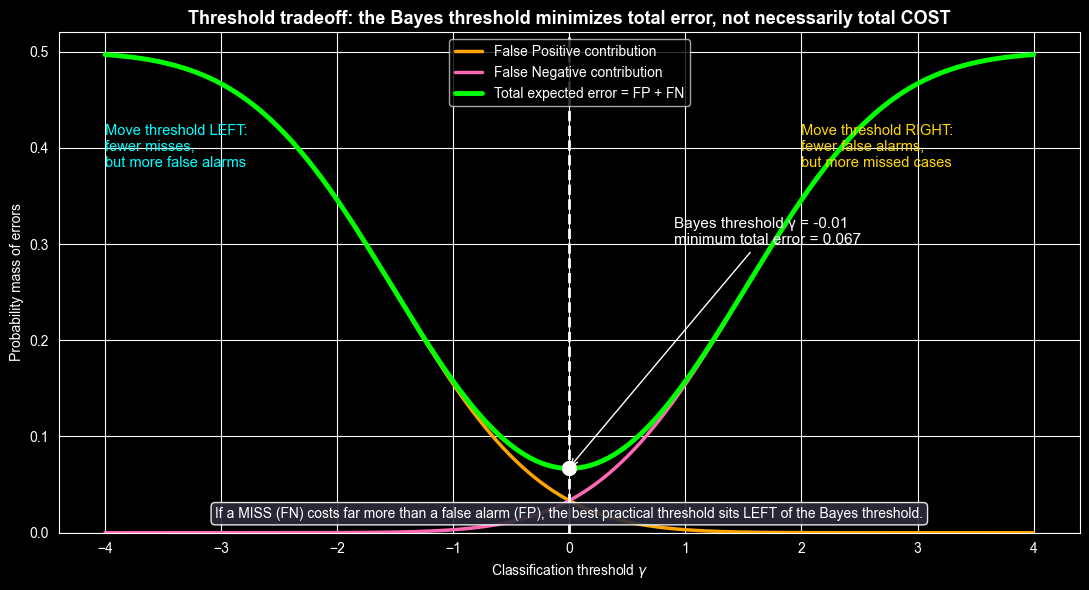

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

mu0, mu1, sigma, pi0, pi1 = -1.5, 1.5, 1.0, 0.5, 0.5
gammas = np.linspace(-4, 4, 600)

fp = pi0 * norm.sf(gammas, mu0, sigma)       # FP shrinks as the threshold moves right
fn = pi1 * norm.cdf(gammas, mu1, sigma)      # FN grows as the threshold moves right
total = fp + fn
best = gammas[total.argmin()]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(gammas, fp, color="orange", lw=2.5, label="False Positive contribution")
ax.plot(gammas, fn, color="hotpink", lw=2.5, label="False Negative contribution")
ax.plot(gammas, total, color="lime", lw=3.5, label="Total expected error = FP + FN")
ax.axvline(best, color="white", ls="--", lw=2)
ax.plot(best, total.min(), "o", color="white", ms=10)

ax.annotate(f"Bayes threshold γ = {best:.2f}\nminimum total error = {total.min():.3f}",
            xy=(best, total.min()), xytext=(0.9, 0.3), color="white", fontsize=11,
            arrowprops=dict(arrowstyle="->", color="white"))
ax.annotate("Move threshold RIGHT:\nfewer false alarms,\nbut more missed cases", xy=(2.2, 0.15), xytext=(2.0, 0.38),
            color="gold", fontsize=10.5, ha="left")
ax.annotate("Move threshold LEFT:\nfewer misses,\nbut more false alarms", xy=(-2.2, 0.15), xytext=(-4.0, 0.38),
            color="cyan", fontsize=10.5, ha="left")
ax.text(0.5, 0.03, "If a MISS (FN) costs far more than a false alarm (FP), the best practical threshold sits LEFT of the Bayes threshold.",
        transform=ax.transAxes, ha="center", fontsize=10, color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

ax.set_xlabel(r"Classification threshold $\gamma$"); ax.set_ylabel("Probability mass of errors")
ax.set_title("Threshold tradeoff: the Bayes threshold minimizes total error, not necessarily total COST", fontsize=13, weight="bold")
ax.legend(loc="upper center", fontsize=10); ax.set_ylim(0, 0.52)
plt.tight_layout(); plt.show()

# Confusion Matrix, Null Classifier & TPR/TNR/FPR/FNR

**Connection:** TP/TN/FP/FN counts → **confusion matrix** → overall error rate (can be misleading!) → **per-class rates** (TPR, TNR, FPR, FNR)

---

## 1. The Confusion Matrix
A table of all four outcomes, with row and column totals. (Layout used in this lecture: **rows = predicted**, **columns = actual**.)

| | Actual $y=0$ | Actual $y=1$ | Total |
|---|---|---|---|
| **Predicted $C=0$** | TN | FN | TN + FN |
| **Predicted $C=1$** | FP | TP | FP + TP |
| **Total** | $N_0=$ TN + FP | $N_1=$ FN + TP | $N$ |

> ⚠️ **Orientation warning:** the previous video's table (and many textbooks/libraries like `sklearn`) put **actual on rows** instead. Always read the row/column labels first; never memorize positions.

$$\text{Error rate}=\frac{\text{FP}+\text{FN}}{N}$$

---

## 2. Example: LDA on the Default Dataset ($N=10{,}000$)

| | Actual: No default | Actual: Default | Total |
|---|---|---|---|
| **Predicted: No default** | 9,644 (TN) | 252 (FN) | 9,896 |
| **Predicted: Default** | 23 (FP) | 81 (TP) | 104 |
| **Total** | 9,667 | 333 | 10,000 |

- FP (23): reliable borrowers wrongly flagged → bank refuses a good customer.
- FN (252): defaulters wrongly approved → **bank loses money**.
- LDA error rate $=\frac{23+252}{10000}=\mathbf{2.75\%}$ (the transcript omits the % sign).

---

## 3. Benchmark: the Null Classifier
**Null classifier:** always predict $0$ ("lend to everyone"). Then TP = FP = 0, FN = 333, TN = 9,667.
$$\text{Null error}=\frac{333}{10000}=\mathbf{3.33\%}$$

**Lesson:** LDA (2.75%) barely beats "do nothing" (3.33%). When one class is rare (only 3.33% default), **overall error rate is a poor performance measure**. Always compare against the null classifier.

> ⚠️ **Wording fix:** the lecture compares this to "an optimal Bayesian classifier". LDA's classifier is only an *estimate* of the Bayes optimal one (parameters estimated from data, Gaussian assumption), so don't treat 2.75% as the true Bayes error.

---

## 4. Per-Class Rates (should memorize)
$$\text{TPR}=\frac{\text{TP}}{\text{TP}+\text{FN}}\quad \text{TNR}=\frac{\text{TN}}{\text{TN}+\text{FP}}\quad \text{FPR}=\frac{\text{FP}}{\text{FP}+\text{TN}}\quad \text{FNR}=\frac{\text{FN}}{\text{FN}+\text{TP}}$$

- Each rate divides by an **actual-class total** ($N_1$ for TPR/FNR, $N_0$ for TNR/FPR). They answer: *"Of the people who really are X, what fraction did we label correctly or incorrectly?"*
- Complements: $\boxed{\text{FPR}=1-\text{TNR}}\qquad \boxed{\text{FNR}=1-\text{TPR}}$
- Also known as: TPR = **sensitivity / recall**, TNR = **specificity**.

**Default example:**

| Rate | Calculation | Value |
|---|---|---|
| FPR | $23/9667$ | ≈ **0.24%** |
| TNR | $9644/9667$ | ≈ 99.76% |
| FNR | $252/333$ | ≈ **75.7%** |
| TPR | $81/333$ | ≈ 24.3% |

> The lecture rounds these to 0.2% and 75%. I'm using unrounded values.

**Interpretation:** LDA almost never harasses good borrowers (FPR tiny) but **catches only ~1 in 4 actual defaulters** (TPR ≈ 24%). The overall error rate hid this completely.

---

## Key Takeaways
1. The confusion matrix organizes TP, TN, FP, FN. Check its **orientation** before reading it.
2. Error rate = (FP + FN) / N treats both mistakes equally and ignores class imbalance.
3. Always compare to the **null classifier** (always predict 0). Here 2.75% vs 3.33% is only a small win.
4. TPR, TNR, FPR, FNR each condition on the **actual class** (divide by $N_1$ or $N_0$).
5. FPR = 1 − TNR and FNR = 1 − TPR.
6. LDA on Default: FPR ≈ 0.24% but FNR ≈ 75.7%, so it misses most defaulters despite a low overall error.

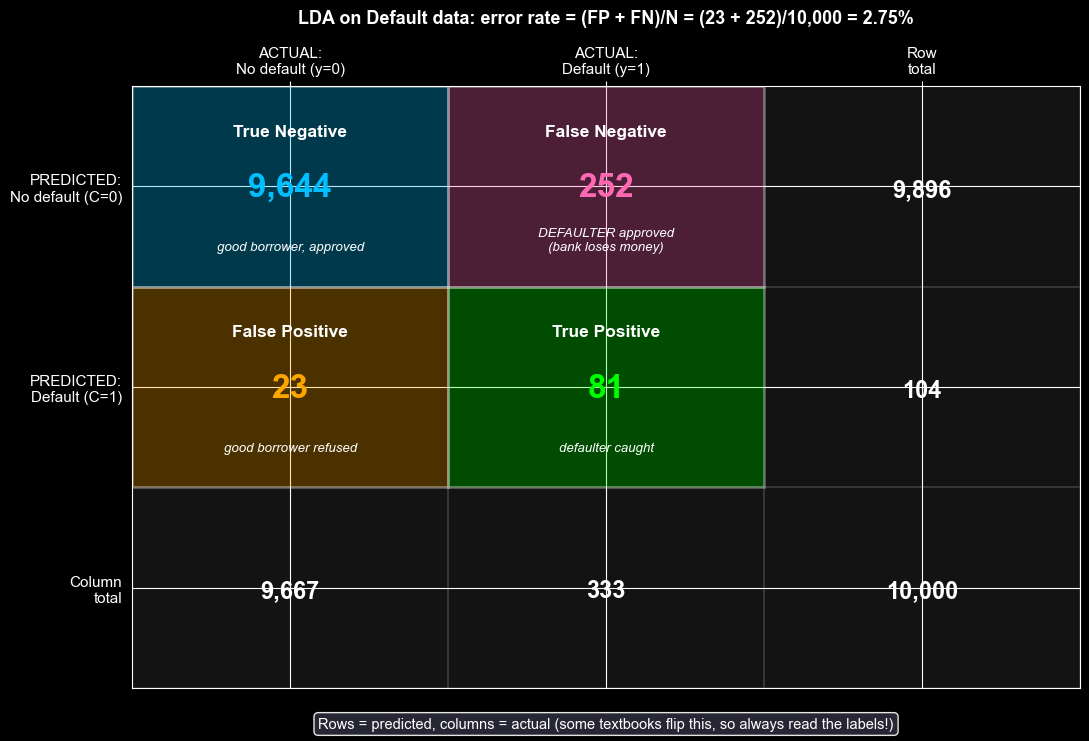

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.style.use("dark_background")

# Default dataset, LDA classifier (rows = predicted, columns = actual)
TN, FN, FP, TP = 9644, 252, 23, 81
N = TN + FN + FP + TP

fig, ax = plt.subplots(figsize=(11, 7.5))

# Main 2x2 cells: (row, col) -> (label, count, color, meaning)
cells = {
    (0, 0): ("True Negative", TN, "deepskyblue", "good borrower, approved"),
    (0, 1): ("False Negative", FN, "hotpink", "DEFAULTER approved\n(bank loses money)"),
    (1, 0): ("False Positive", FP, "orange", "good borrower refused"),
    (1, 1): ("True Positive", TP, "lime", "defaulter caught"),
}
for (r, c), (name, count, col, desc) in cells.items():
    ax.add_patch(Rectangle((c, r), 1, 1, facecolor=col, alpha=0.3, edgecolor="white", lw=2))
    ax.text(c + 0.5, r + 0.25, name, ha="center", fontsize=12.5, weight="bold", color="white")
    ax.text(c + 0.5, r + 0.55, f"{count:,}", ha="center", fontsize=24, weight="bold", color=col)
    ax.text(c + 0.5, r + 0.82, desc, ha="center", fontsize=9.5, style="italic", color="white")

# Margin totals (row sums, column sums, grand total N)
totals = {(0, 2): TN + FN, (1, 2): FP + TP, (2, 0): TN + FP, (2, 1): FN + TP, (2, 2): N}
for (r, c), val in totals.items():
    ax.add_patch(Rectangle((c, r), 1, 1, facecolor="white", alpha=0.08, edgecolor="white", lw=1.5))
    ax.text(c + 0.5, r + 0.55, f"{val:,}", ha="center", fontsize=17, color="white", weight="bold")

ax.set_xlim(0, 3); ax.set_ylim(3, 0)
ax.set_xticks([0.5, 1.5, 2.5]); ax.set_xticklabels(["ACTUAL:\nNo default (y=0)", "ACTUAL:\nDefault (y=1)", "Row\ntotal"], fontsize=11)
ax.set_yticks([0.5, 1.5, 2.5]); ax.set_yticklabels(["PREDICTED:\nNo default (C=0)", "PREDICTED:\nDefault (C=1)", "Column\ntotal"], fontsize=11)
ax.xaxis.tick_top()
ax.set_title(f"LDA on Default data: error rate = (FP + FN)/N = ({FP} + {FN})/{N:,} = {(FP+FN)/N:.2%}",
             fontsize=13, weight="bold", pad=45)
ax.text(1.5, 3.2, "Rows = predicted, columns = actual (some textbooks flip this, so always read the labels!)",
        ha="center", fontsize=10.5, color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))
plt.tight_layout(); plt.show()

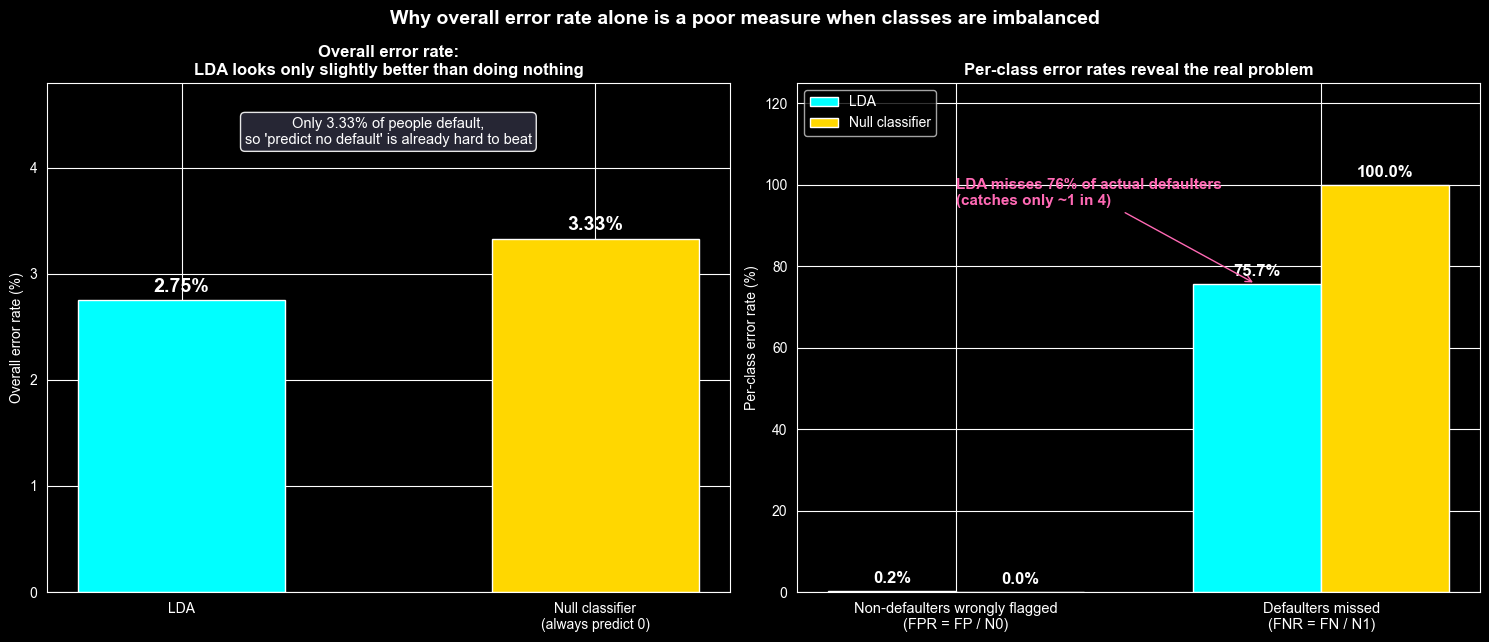

In [32]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

TN, FN, FP, TP = 9644, 252, 23, 81
N = TN + FN + FP + TP
N0, N1 = TN + FP, FN + TP

# LDA vs NULL classifier (always predicts "no default")
lda_err, null_err = (FP + FN) / N * 100, N1 / N * 100
lda_fpr, lda_fnr = FP / N0 * 100, FN / N1 * 100
null_fpr, null_fnr = 0.0, 100.0

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# LEFT: overall error rate
bars = axes[0].bar(["LDA", "Null classifier\n(always predict 0)"], [lda_err, null_err], color=["cyan", "gold"], width=0.5)
for b, v in zip(bars, [lda_err, null_err]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.08, f"{v:.2f}%", ha="center", fontsize=14, weight="bold", color="white")
axes[0].set_ylim(0, 4.8); axes[0].set_ylabel("Overall error rate (%)")
axes[0].set_title("Overall error rate:\nLDA looks only slightly better than doing nothing", fontsize=12, weight="bold")
axes[0].text(0.5, 0.88, "Only 3.33% of people default,\nso 'predict no default' is already hard to beat",
             transform=axes[0].transAxes, ha="center", fontsize=10.5, color="white",
             bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

# RIGHT: per-class error rates
groups = ["Non-defaulters wrongly flagged\n(FPR = FP / N0)", "Defaulters missed\n(FNR = FN / N1)"]
xpos = np.arange(2); w = 0.35
b1 = axes[1].bar(xpos - w/2, [lda_fpr, lda_fnr], w, color="cyan", label="LDA")
b2 = axes[1].bar(xpos + w/2, [null_fpr, null_fnr], w, color="gold", label="Null classifier")
for bars_ in (b1, b2):
    for b in bars_:
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 2, f"{b.get_height():.1f}%", ha="center", fontsize=12, weight="bold", color="white")
axes[1].set_xticks(xpos); axes[1].set_xticklabels(groups, fontsize=10.5)
axes[1].set_ylim(0, 125); axes[1].set_ylabel("Per-class error rate (%)")
axes[1].set_title("Per-class error rates reveal the real problem", fontsize=12, weight="bold")
axes[1].legend(loc="upper left", fontsize=10)
axes[1].annotate(f"LDA misses {lda_fnr:.0f}% of actual defaulters\n(catches only ~1 in 4)", xy=(0.82, lda_fnr), xytext=(0.0, 95),
                 color="hotpink", fontsize=11, weight="bold", arrowprops=dict(arrowstyle="->", color="hotpink"))

fig.suptitle("Why overall error rate alone is a poor measure when classes are imbalanced", fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

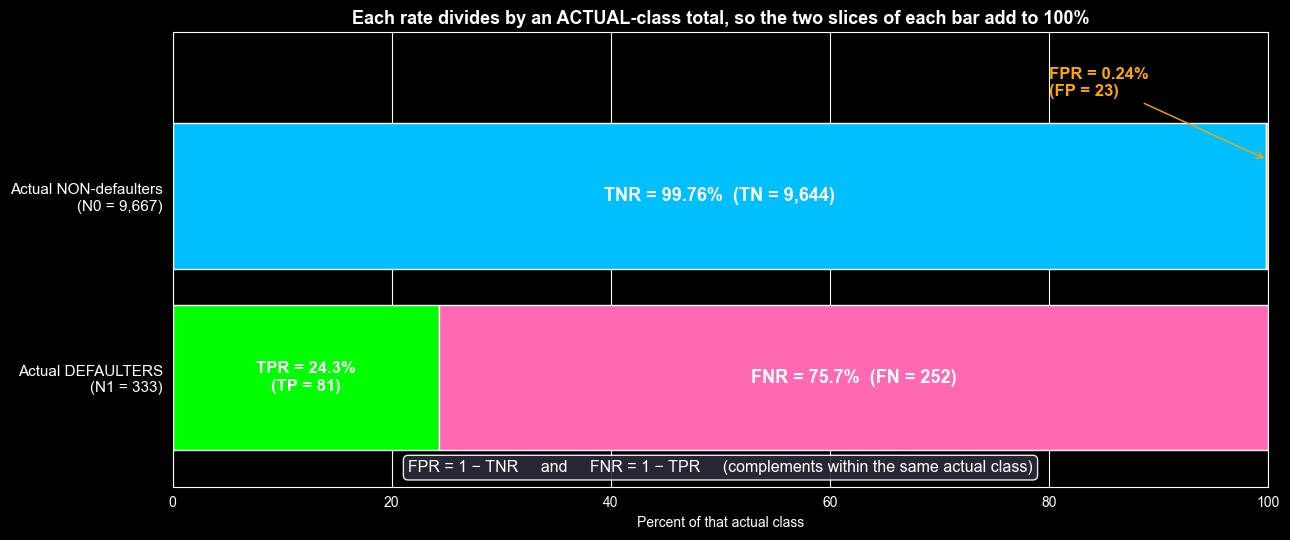

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

TN, FN, FP, TP = 9644, 252, 23, 81
N0, N1 = TN + FP, FN + TP
tnr, fpr = TN / N0 * 100, FP / N0 * 100       # fractions of the 9,667 actual non-defaulters
tpr, fnr = TP / N1 * 100, FN / N1 * 100       # fractions of the 333 actual defaulters

fig, ax = plt.subplots(figsize=(13, 5.5))

# Each bar = 100% of one ACTUAL class, split into correct vs incorrect
ax.barh(1, tnr, color="deepskyblue", edgecolor="white")
ax.barh(1, fpr, left=tnr, color="orange", edgecolor="white")
ax.barh(0, tpr, color="lime", edgecolor="white")
ax.barh(0, fnr, left=tpr, color="hotpink", edgecolor="white")

ax.text(tnr/2, 1, f"TNR = {tnr:.2f}%  (TN = {TN:,})", ha="center", va="center", fontsize=13, weight="bold", color="white")
ax.annotate(f"FPR = {fpr:.2f}%\n(FP = {FP})", xy=(tnr + fpr/2, 1.2), xytext=(80, 1.55),
            color="orange", fontsize=12, weight="bold", arrowprops=dict(arrowstyle="->", color="orange"))
ax.text(tpr/2, 0, f"TPR = {tpr:.1f}%\n(TP = {TP})", ha="center", va="center", fontsize=12, weight="bold", color="white")
ax.text(tpr + fnr/2, 0, f"FNR = {fnr:.1f}%  (FN = {FN})", ha="center", va="center", fontsize=13, weight="bold", color="white")

ax.set_yticks([1, 0])
ax.set_yticklabels([f"Actual NON-defaulters\n(N0 = {N0:,})", f"Actual DEFAULTERS\n(N1 = {N1})"], fontsize=11)
ax.set_xlim(0, 100); ax.set_ylim(-0.6, 1.9)
ax.set_xlabel("Percent of that actual class")
ax.set_title("Each rate divides by an ACTUAL-class total, so the two slices of each bar add to 100%", fontsize=13, weight="bold")
ax.text(50, -0.52, "FPR = 1 − TNR     and     FNR = 1 − TPR     (complements within the same actual class)",
        ha="center", fontsize=11.5, color="white", bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))
plt.tight_layout(); plt.show()

# Expected False Positives & False Negatives in LDA

**Connection:** counting FP/FN in a data set → **expectation** over the LDA generative model → tail areas of $\pi_k f_k$ → expected error. This formalizes the "overlapping tail areas" picture from the earlier error video.

---

## Goal
If we know the true ingredients ($\pi_0,\pi_1,f_0,f_1$), we can compute the **expected** number of mistakes of the Bayes classifier with **no data at all**, as a theory calculation.

Recall the counting formula (indicator, $\delta(a)=1$ if $a=0$ else $0$):
$$\#\text{FP}=\sum_{i=1}^{N}\delta\big(C(X_i)-1\big)\,\delta(Y_i)$$
i.e., "classifier says 1" **and** "truth is 0".

---

## Derivation of $E[\#\text{FP}]$ (understand the steps, don't memorize)

| Step | What happens | Why |
|---|---|---|
| 1 | $E[\#\text{FP}]=\sum_{i=1}^N E\big[\delta(C(X_i)-1)\,\delta(Y_i)\big]$ | **Linearity** of expectation: move $E$ inside the sum |
| 2 | Each term is identical, so $=N\cdot E\big[\delta(C(X)-1)\,\delta(Y)\big]$ | Samples are **i.i.d.** from the same model |
| 3 | $=N\sum_{y\in\{0,1\}}E\big[\delta(C(X)-1)\,\delta(y)\mid Y=y\big]\,P(Y=y)$ | **Law of total expectation** ($X$ continuous, $Y$ discrete) |
| 4 | The $y=1$ term vanishes ($\delta(1)=0$); the $y=0$ term has $\delta(0)=1$ and weight $\pi_0$ | Only **actual negatives** can be false positives |
| 5 | $=N\,\pi_0\int \delta\big(C(x)-1\big)\,f_0(x)\,dx$ | Definition of conditional expectation: $\int(\cdot)\,f_{X\mid Y=0}(x)\,dx$ |
| 6 | $\delta(C(x)-1)=1$ exactly when $x\ge\gamma$ (Bayes rule), so the integral runs over $[\gamma,\infty)$ | Indicator becomes the **integration region** |

---

## Final Results (should memorize)
$$\boxed{E[\#\text{FP}]=N\,\pi_0\int_{\gamma}^{\infty}f_0(x)\,dx}\qquad\quad \boxed{E[\#\text{FN}]=N\,\pi_1\int_{-\infty}^{\gamma}f_1(x)\,dx}$$

$$\text{Expected error rate}=\frac{E[\#\text{FP}]+E[\#\text{FN}]}{N}=\pi_0\!\int_\gamma^\infty\! f_0+\pi_1\!\int_{-\infty}^{\gamma}\! f_1$$

**Gaussian case** (conceptual): with $f_k=\mathcal{N}(\mu_k,\sigma^2)$ these integrals are normal tail probabilities, e.g. $\int_\gamma^\infty f_0=1-\Phi\!\big(\tfrac{\gamma-\mu_0}{\sigma}\big)$.

---

## Graphical Meaning
- **E[FP] / N** = area under $\pi_0 f_0(x)$ to the **right** of $\gamma$ (class-0 mass that crosses into the "predict 1" zone).
- **E[FN] / N** = area under $\pi_1 f_1(x)$ to the **left** of $\gamma$ (class-1 mass that falls into the "predict 0" zone).
- Multiply the area by $N$ to get an expected **count**.

> ⚠️ **Fine print:**
> - The limits assume class 0 lies to the **left** of class 1 ($x<\gamma\Rightarrow$ predict 0).
> - Step 2 relies on the samples being **i.i.d.** from the LDA model. A real data set will fluctuate **around** these expectations; the formulas describe the long-run average.
> - The lecture says "expectation of $X$ and $Y$"; it means the expectation of the function $g(X,Y)$ over the joint distribution of $(X,Y)$. Also "$\pi_1$ one" is a typo for $\pi_1 f_1$.

---

## Key Takeaways
1. With known LDA ingredients, FP and FN counts have **closed-form expected values**. No data needed.
2. The proof uses **linearity of expectation** + **law of total expectation** + the indicator becoming an **integration limit**.
3. $E[\#\text{FP}]=N\pi_0\int_\gamma^\infty f_0$, the weighted class-0 tail beyond $\gamma$.
4. $E[\#\text{FN}]=N\pi_1\int_{-\infty}^\gamma f_1$, the weighted class-1 tail below $\gamma$.
5. Geometrically these are the **overlap areas** of $\pi_0 f_0$ and $\pi_1 f_1$ on either side of $\gamma$, times $N$.
6. These are **long-run averages**; any one data set will vary around them.

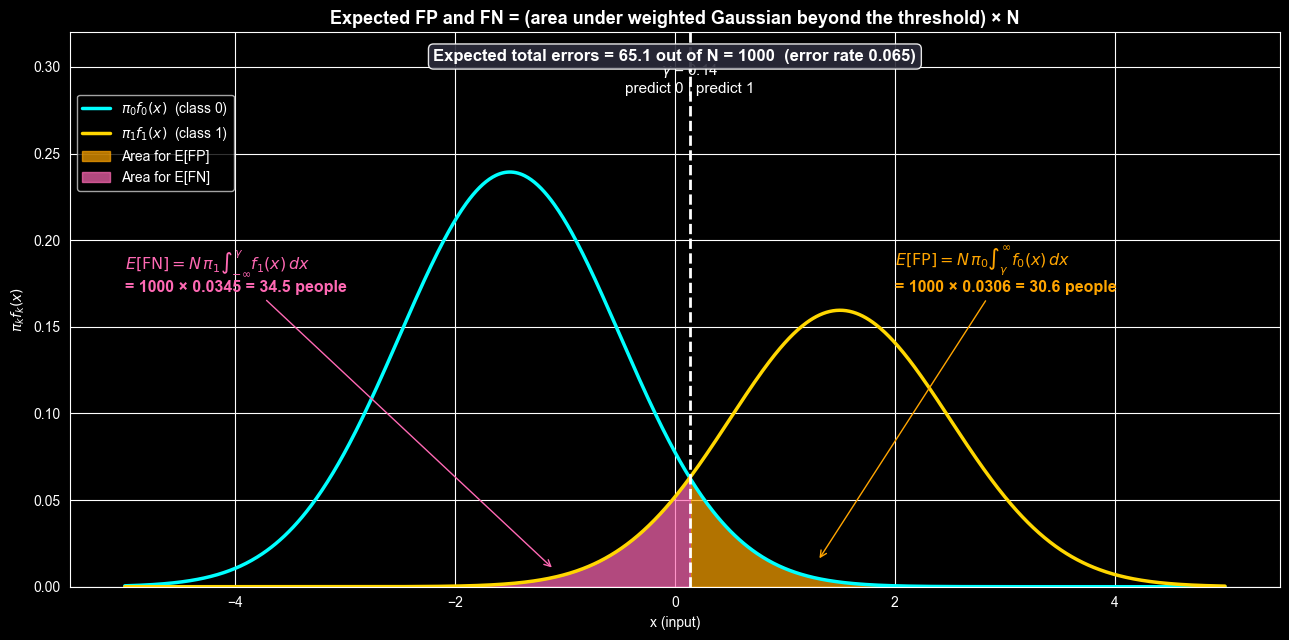

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

# LDA ingredients (class 0 on the left, class 1 on the right), unequal priors
mu0, mu1, sigma = -1.5, 1.5, 1.0
pi0, pi1, N = 0.6, 0.4, 1000
gamma = (mu0 + mu1)/2 + sigma**2 * np.log(pi0/pi1)/(mu1 - mu0)     # Bayes threshold

x = np.linspace(-5, 5, 1000)
g0, g1 = pi0*norm.pdf(x, mu0, sigma), pi1*norm.pdf(x, mu1, sigma)   # pi_k f_k(x)

# The two integrals from the lecture (areas), times N = expected counts
fp_area = pi0 * norm.sf(gamma, mu0, sigma)       # pi0 * integral_{gamma}^{inf} f0
fn_area = pi1 * norm.cdf(gamma, mu1, sigma)      # pi1 * integral_{-inf}^{gamma} f1

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(x, g0, color="cyan", lw=2.5, label=r"$\pi_0 f_0(x)$  (class 0)")
ax.plot(x, g1, color="gold", lw=2.5, label=r"$\pi_1 f_1(x)$  (class 1)")
ax.fill_between(x, 0, g0, where=x >= gamma, color="orange", alpha=0.7, label="Area for E[FP]")
ax.fill_between(x, 0, g1, where=x < gamma, color="hotpink", alpha=0.7, label="Area for E[FN]")
ax.axvline(gamma, color="white", ls="--", lw=2)
ax.text(gamma, 0.285, rf"$\gamma$ = {gamma:.2f}" + "\npredict 0 | predict 1", ha="center", fontsize=11, color="white")

ax.annotate(r"$E[\mathrm{FP}] = N\,\pi_0\int_{\gamma}^{\infty} f_0(x)\,dx$" + f"\n= {N} × {fp_area:.4f} = {N*fp_area:.1f} people",
            xy=(1.3, 0.015), xytext=(2.0, 0.17), color="orange", fontsize=11.5, weight="bold",
            arrowprops=dict(arrowstyle="->", color="orange"))
ax.annotate(r"$E[\mathrm{FN}] = N\,\pi_1\int_{-\infty}^{\gamma} f_1(x)\,dx$" + f"\n= {N} × {fn_area:.4f} = {N*fn_area:.1f} people",
            xy=(-1.1, 0.01), xytext=(-5.0, 0.17), color="hotpink", fontsize=11.5, weight="bold",
            arrowprops=dict(arrowstyle="->", color="hotpink"))
ax.text(0.5, 0.97, f"Expected total errors = {N*(fp_area+fn_area):.1f} out of N = {N}  (error rate {fp_area+fn_area:.3f})",
        transform=ax.transAxes, ha="center", va="top", fontsize=12, weight="bold", color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

ax.set_xlabel("x (input)"); ax.set_ylabel(r"$\pi_k f_k(x)$"); ax.set_ylim(0, 0.32)
ax.set_title("Expected FP and FN = (area under weighted Gaussian beyond the threshold) × N", fontsize=13, weight="bold")
ax.legend(loc="upper left", fontsize=10, bbox_to_anchor=(0.0, 0.9))
plt.tight_layout(); plt.show()

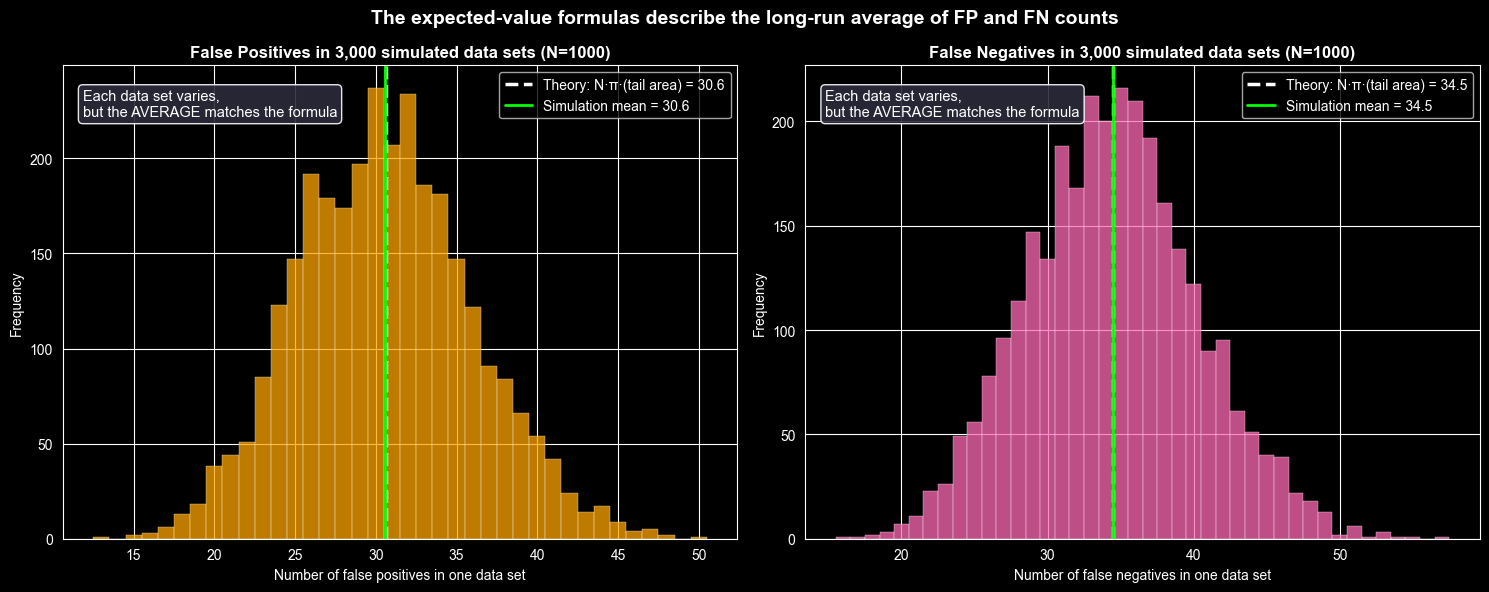

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")
rng = np.random.default_rng(7)

mu0, mu1, sigma, pi0, pi1, N = -1.5, 1.5, 1.0, 0.6, 0.4, 1000
gamma = (mu0 + mu1)/2 + sigma**2 * np.log(pi0/pi1)/(mu1 - mu0)

# Theory: closed-form expectations
E_fp = N * pi0 * norm.sf(gamma, mu0, sigma)
E_fn = N * pi1 * norm.cdf(gamma, mu1, sigma)

# Simulation: draw many data sets from the LDA generative process, count FP and FN with the Bayes classifier
sims = 3000
y = rng.random((sims, N)) < pi1                                        # label first (True = class 1) ...
x = np.where(y, rng.normal(mu1, sigma, (sims, N)), rng.normal(mu0, sigma, (sims, N)))  # ... then the input
C = x >= gamma                                                         # Bayes optimal predictions
FP = (C & ~y).sum(axis=1)                                              # predicted 1, actually 0
FN = (~C & y).sum(axis=1)                                              # predicted 0, actually 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, counts, theory, color, name in [(axes[0], FP, E_fp, "orange", "False Positives"),
                                        (axes[1], FN, E_fn, "hotpink", "False Negatives")]:
    ax.hist(counts, bins=np.arange(counts.min(), counts.max() + 2) - 0.5, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(theory, color="white", ls="--", lw=2.5, label=f"Theory: N·π·(tail area) = {theory:.1f}")
    ax.axvline(counts.mean(), color="lime", lw=2, label=f"Simulation mean = {counts.mean():.1f}")
    ax.set_title(f"{name} in {sims:,} simulated data sets (N={N})", fontsize=12, weight="bold")
    ax.set_xlabel(f"Number of {name.lower()} in one data set"); ax.set_ylabel("Frequency")
    ax.legend(loc="upper right", fontsize=10)
    ax.text(0.03, 0.95, "Each data set varies,\nbut the AVERAGE matches the formula", transform=ax.transAxes, va="top",
            fontsize=10.5, color="white", bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))
fig.suptitle("The expected-value formulas describe the long-run average of FP and FN counts", fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

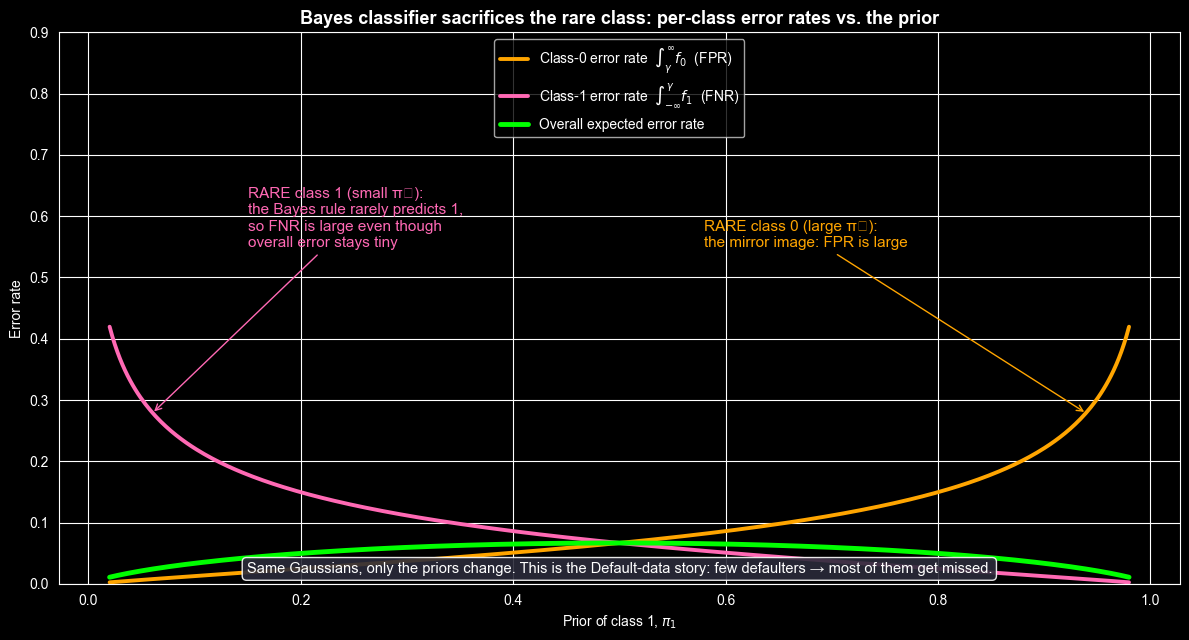

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

mu0, mu1, sigma = -1.5, 1.5, 1.0
pi1 = np.linspace(0.02, 0.98, 400); pi0 = 1 - pi1
gamma = (mu0 + mu1)/2 + sigma**2 * np.log(pi0/pi1)/(mu1 - mu0)       # Bayes threshold moves with the priors

fpr = norm.sf(gamma, mu0, sigma)           # integral_{gamma}^{inf} f0  : fraction of class 0 misclassified
fnr = norm.cdf(gamma, mu1, sigma)          # integral_{-inf}^{gamma} f1 : fraction of class 1 misclassified
err = pi0*fpr + pi1*fnr                    # overall expected error rate (E[FP]+E[FN])/N

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(pi1, fpr, color="orange", lw=2.8, label=r"Class-0 error rate  $\int_\gamma^\infty f_0$  (FPR)")
ax.plot(pi1, fnr, color="hotpink", lw=2.8, label=r"Class-1 error rate  $\int_{-\infty}^{\gamma} f_1$  (FNR)")
ax.plot(pi1, err, color="lime", lw=3.5, label="Overall expected error rate")

ax.annotate("RARE class 1 (small π₁):\nthe Bayes rule rarely predicts 1,\nso FNR is large even though\noverall error stays tiny",
            xy=(0.06, fnr[np.argmin(abs(pi1 - 0.06))]), xytext=(0.15, 0.55), color="hotpink", fontsize=11,
            arrowprops=dict(arrowstyle="->", color="hotpink"))
ax.annotate("RARE class 0 (large π₁):\nthe mirror image: FPR is large", xy=(0.94, fpr[np.argmin(abs(pi1 - 0.94))]),
            xytext=(0.58, 0.55), color="orange", fontsize=11, arrowprops=dict(arrowstyle="->", color="orange"))
ax.text(0.5, 0.02, "Same Gaussians, only the priors change. This is the Default-data story: few defaulters → most of them get missed.",
        transform=ax.transAxes, ha="center", fontsize=10.5, color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

ax.set_xlabel(r"Prior of class 1, $\pi_1$"); ax.set_ylabel("Error rate"); ax.set_ylim(0, 0.9)
ax.set_title("Bayes classifier sacrifices the rare class: per-class error rates vs. the prior", fontsize=13, weight="bold")
ax.legend(loc="upper center", fontsize=10)
plt.tight_layout(); plt.show()

# Choosing a Classifier: Cost-Sensitive Thresholds, ROC & AUC

**Connection:** TP/FP/FN/TN → TPR/FPR/FNR → Bayes classifier (minimizes total error) → **threshold $\tau$ trades FN vs FP** → **ROC curve** → **AUC** (compare whole families of classifiers)

---

## 1. Why Not Just Minimize Total Error?
FP and FN usually have **different costs**:
- **Medical:** FN (telling a sick patient "no cancer") ≫ FP (extra tests, then good news).
- **Bank:** FN (lend to someone who defaults) ≫ FP (refuse a good customer, lose financing income).

The Bayes classifier minimizes the **total error rate**, so it is **cost-optimal only if FP and FN cost the same**.

---

## 2. The Bayes Classifier as a Threshold Rule
For binary $Y\in\{0,1\}$, $P(Y=1\mid x)+P(Y=0\mid x)=1$, so:
$$C_{\text{Bayes}}(x)=\begin{cases}1 & P(Y=1\mid x)\ge \tfrac12\\ 0 & P(Y=1\mid x)<\tfrac12\end{cases}$$
(Class 1 wins exactly when its probability is at least $\tfrac12$.)

## 3. The Threshold Classifier $C_\tau$
$$\boxed{C_\tau(x)=\begin{cases}1 & P(Y=1\mid x)\ge \tau\\ 0 & P(Y=1\mid x)<\tau\end{cases}}\qquad \tau\in[0,1]$$
- $\tau=\tfrac12$ → Bayes optimal classifier.
- $P(Y=1\mid x)$ comes from LDA via Bayes' theorem ($\pi_k f_k$ ratio), so all error rates can be computed for any $\tau$.

| $\tau$ | Behavior | FPR | FNR |
|---|---|---|---|
| $0$ | everyone predicted **1** (all positive) | $1$ | $0$ |
| $\tfrac12$ | Bayes classifier | $\approx 0.24\%$ | $\approx 75.7\%$ (Default) |
| $1$ | everyone predicted **0** (null classifier) | $0$ | $1$ |

**Rule of thumb:** as $\tau$ **increases**, FNR **increases** and FPR **decreases** (both monotonic).
- **Lowering $\tau$** (below $\tfrac12$) → catch more positives (FNR ↓) but more false alarms (FPR ↑); total error rate goes **up**.
- That's worth it when a **cost-weighted** error is what matters, e.g. missing a defaulter/cancer is expensive.

> ⚠️ **Typo fixes:** the lecture says "FPI" for FPR, and quotes FNR "75" and FPR "0.2%"; unrounded they are 75.7% and 0.24%.

---

## 4. ROC Curve
**ROC** (Receiver Operating Characteristic) plots **TPR (y-axis) vs FPR (x-axis)** as $\tau$ sweeps from 0 to 1. Remember $\text{TPR}=1-\text{FNR}$.

| Point | Meaning |
|---|---|
| $(0,0)$ | $\tau=1$: null classifier (predict all 0) |
| $(1,1)$ | $\tau=0$: predict all 1 |
| $(0,1)$ top-left | **Ideal**: no false alarms, catches every positive |
| Bayes ($\tau=\tfrac12$) | Low FPR, but TPR only $\approx 24\%$ on Default |

**Reading it:** moving **up-and-right along the curve = lowering $\tau$** (more TPR, but more FPR). The curve shows every trade-off you could choose.

**Coin-flip classifier:** predict 1 with probability $\tau$ regardless of $x$. Then $\text{FPR}=\text{TPR}=\tau$ → the **diagonal**. It is the "no skill" baseline.

---

## 5. AUC (Area Under the ROC Curve)
$$\text{AUC}=\text{area under the ROC curve}\in[0,1]$$
- **AUC = 0.5** → coin flip (no skill). **AUC = 1** → perfect (curve hugs the top-left corner). Higher is better.
- AUC scores the **whole family** $\{C_\tau\}$, not one single threshold.

---

## 6. Choosing $\tau$ with Costs *(understand, don't memorize)*
With costs $c_{FN}$ and $c_{FP}$, predict 1 when the expected cost of missing exceeds the expected cost of a false alarm:
$$c_{FN}\,P(Y=1\mid x)\ \ge\ c_{FP}\,P(Y=0\mid x)\ \Longleftrightarrow\ P(Y=1\mid x)\ge \tau^*=\frac{c_{FP}}{c_{FP}+c_{FN}}$$
Equal costs → $\tau^*=\tfrac12$ (Bayes). FN 5× costlier → $\tau^*=\tfrac16$. This extension goes beyond the video but follows directly from its idea.

---

## Key Takeaways
1. FP and FN rarely cost the same, so **minimizing total error is not always the goal**.
2. $C_\tau$ predicts 1 when $P(Y=1\mid x)\ge\tau$; $\tau=\tfrac12$ is the Bayes classifier.
3. Raising $\tau$: FNR ↑, FPR ↓. Lowering $\tau$: FNR ↓, FPR ↑ (and total error ↑).
4. **ROC** plots TPR vs FPR across all $\tau$. Top-left is ideal; the diagonal is random guessing.
5. **AUC** summarizes a classifier family: 0.5 = chance, 1 = perfect.
6. Next up: **resampling methods**. Read ISLR section 4.4 and do the assessments.

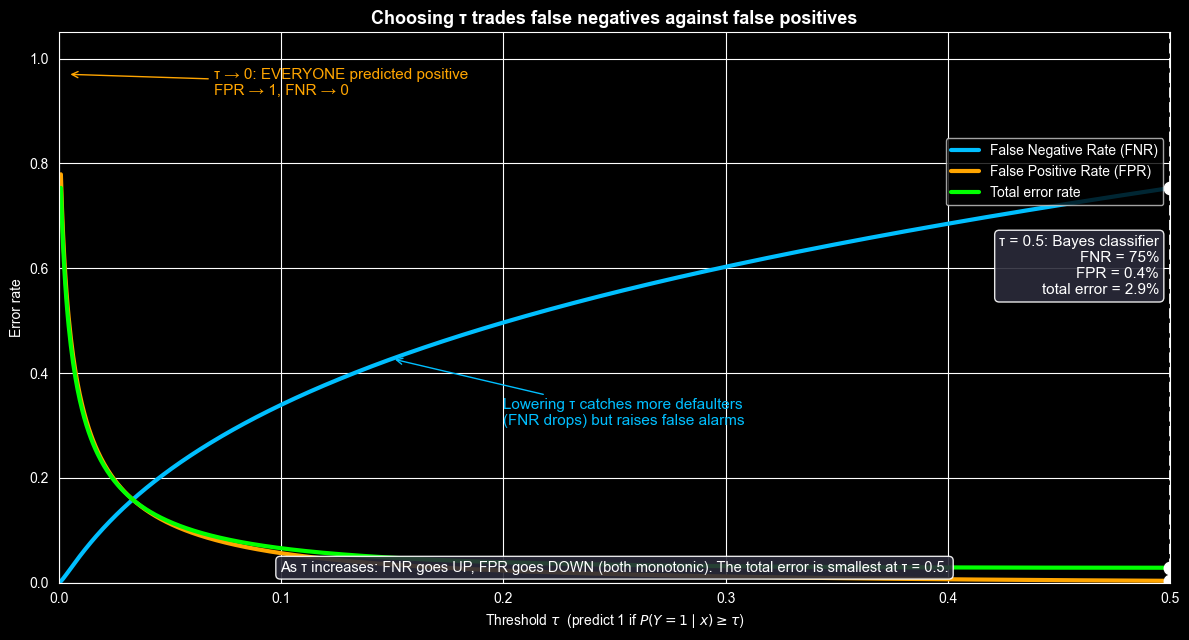

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

# Simulated LDA model that mimics Default: rare positive class (~3.3%), shared variance
mu0, mu1, sigma = 0.0, 2.0, 1.0
pi1 = 0.0333; pi0 = 1 - pi1

def x_threshold(tau):
    """x where P(Y=1|x) = tau (logit of the LDA posterior is linear in x)."""
    return (mu0 + mu1)/2 + sigma**2 * (np.log(tau/(1 - tau)) - np.log(pi1/pi0)) / (mu1 - mu0)

tau = np.linspace(0.001, 0.5, 1000)
xt = x_threshold(tau)
fpr = norm.sf(xt, mu0, sigma)                 # fraction of actual negatives predicted positive
fnr = norm.cdf(xt, mu1, sigma)                # fraction of actual positives predicted negative
total_err = pi0*fpr + pi1*fnr                 # overall error rate

x_bayes = x_threshold(0.5)
fpr_b, fnr_b = norm.sf(x_bayes, mu0, sigma), norm.cdf(x_bayes, mu1, sigma)
err_b = pi0*fpr_b + pi1*fnr_b

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(tau, fnr, color="deepskyblue", lw=3, label="False Negative Rate (FNR)")
ax.plot(tau, fpr, color="orange", lw=3, label="False Positive Rate (FPR)")
ax.plot(tau, total_err, color="lime", lw=3, label="Total error rate")
ax.axvline(0.5, color="white", ls="--", lw=2)
ax.plot([0.5]*3, [fnr_b, fpr_b, err_b], "o", color="white", ms=9)

ax.text(0.495, 0.55, f"τ = 0.5: Bayes classifier\nFNR = {fnr_b:.0%}\nFPR = {fpr_b:.1%}\ntotal error = {err_b:.1%}",
        ha="right", fontsize=11, color="white", bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))
ax.annotate("τ → 0: EVERYONE predicted positive\nFPR → 1, FNR → 0", xy=(0.004, 0.97), xytext=(0.07, 0.93),
            color="orange", fontsize=11, arrowprops=dict(arrowstyle="->", color="orange"))
ax.annotate("Lowering τ catches more defaulters\n(FNR drops) but raises false alarms", xy=(0.15, fnr[np.argmin(abs(tau - 0.15))]),
            xytext=(0.2, 0.3), color="deepskyblue", fontsize=11, arrowprops=dict(arrowstyle="->", color="deepskyblue"))
ax.text(0.5, 0.02, "As τ increases: FNR goes UP, FPR goes DOWN (both monotonic). The total error is smallest at τ = 0.5.",
        transform=ax.transAxes, ha="center", fontsize=10.5, color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

ax.set_xlabel(r"Threshold $\tau$  (predict 1 if $P(Y=1\mid x) \geq \tau$)"); ax.set_ylabel("Error rate")
ax.set_xlim(0, 0.5); ax.set_ylim(0, 1.05)
ax.set_title("Choosing τ trades false negatives against false positives", fontsize=13, weight="bold")
ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(1.0, 0.82))
plt.tight_layout(); plt.show()

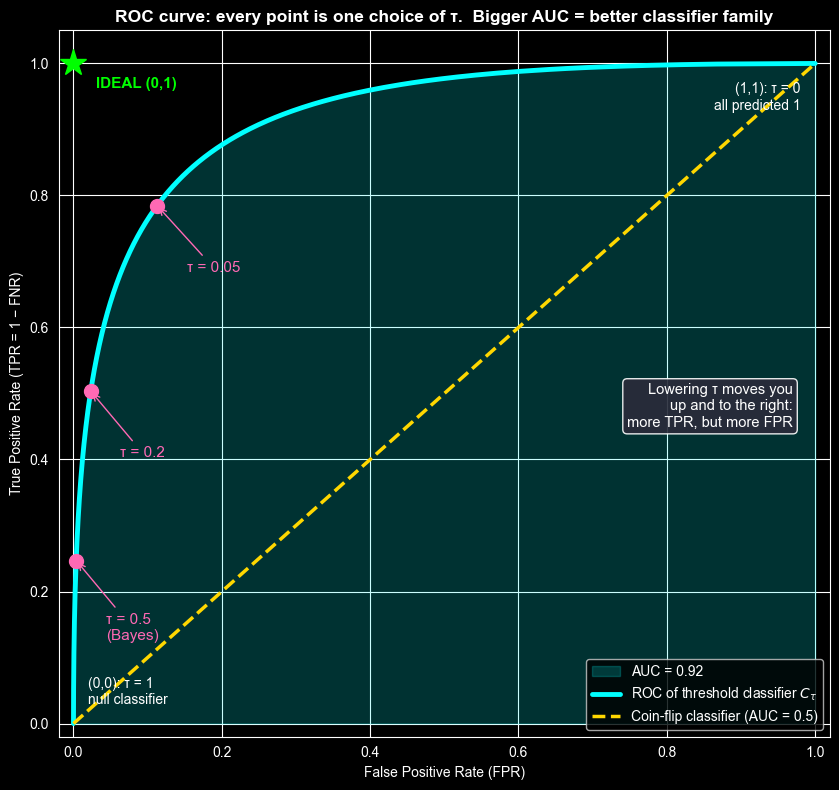

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

mu0, mu1, sigma = 0.0, 2.0, 1.0
pi1 = 0.0333; pi0 = 1 - pi1

def x_threshold(tau):
    return (mu0 + mu1)/2 + sigma**2 * (np.log(tau/(1 - tau)) - np.log(pi1/pi0)) / (mu1 - mu0)

# Sweep tau over (0,1); add the endpoints tau=0 -> (1,1) and tau=1 -> (0,0)
tau = np.linspace(0.0005, 0.9995, 4000)
xt = x_threshold(tau)
fpr = np.concatenate([[1.0], norm.sf(xt, mu0, sigma), [0.0]])
tpr = np.concatenate([[1.0], norm.sf(xt, mu1, sigma), [0.0]])      # TPR = 1 - FNR

order = np.argsort(fpr)                                            # sort by FPR for plotting / integrating
fpr_s, tpr_s = fpr[order], tpr[order]
trapezoid = getattr(np, "trapezoid", None) or np.trapz
auc = trapezoid(tpr_s, fpr_s)                                      # area under the ROC curve

fig, ax = plt.subplots(figsize=(8.5, 8))
ax.fill_between(fpr_s, 0, tpr_s, color="cyan", alpha=0.2, label=f"AUC = {auc:.2f}")
ax.plot(fpr_s, tpr_s, color="cyan", lw=3.5, label=r"ROC of threshold classifier $C_\tau$")
ax.plot([0, 1], [0, 1], color="gold", ls="--", lw=2.5, label="Coin-flip classifier (AUC = 0.5)")

# Highlight a few thresholds
for t, lab, dx, dy in [(0.5, "τ = 0.5\n(Bayes)", 0.04, -0.12), (0.2, "τ = 0.2", 0.04, -0.10), (0.05, "τ = 0.05", 0.04, -0.10)]:
    f, tp_ = norm.sf(x_threshold(t), mu0, sigma), norm.sf(x_threshold(t), mu1, sigma)
    ax.plot(f, tp_, "o", color="hotpink", ms=10)
    ax.annotate(lab, xy=(f, tp_), xytext=(f + dx, tp_ + dy), color="hotpink", fontsize=11, arrowprops=dict(arrowstyle="->", color="hotpink"))

ax.plot(0, 1, "*", color="lime", ms=20); ax.text(0.03, 0.98, "IDEAL (0,1)", color="lime", fontsize=11, weight="bold", va="top")
ax.text(0.02, 0.03, "(0,0): τ = 1\nnull classifier", color="white", fontsize=10)
ax.text(0.98, 0.93, "(1,1): τ = 0\nall predicted 1", color="white", fontsize=10, ha="right")
ax.text(0.97, 0.45, "Lowering τ moves you\nup and to the right:\nmore TPR, but more FPR", color="white", fontsize=10.5, ha="right",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))

ax.set_xlabel("False Positive Rate (FPR)"); ax.set_ylabel("True Positive Rate (TPR = 1 − FNR)")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.set_title("ROC curve: every point is one choice of τ.  Bigger AUC = better classifier family", fontsize=12.5, weight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout(); plt.show()

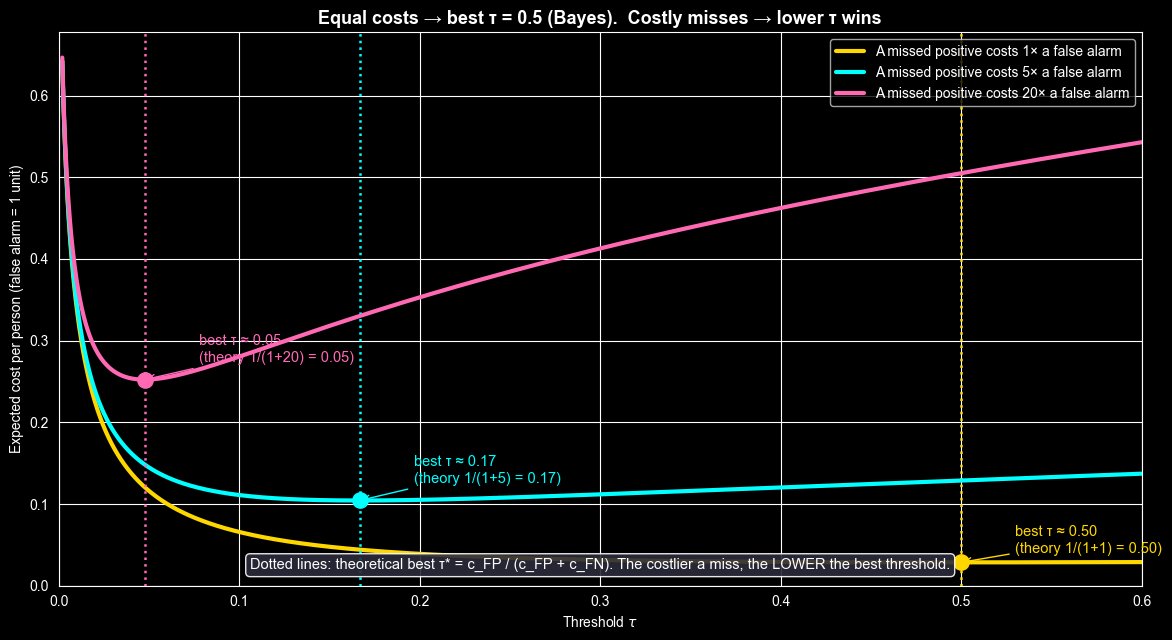

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("dark_background")

mu0, mu1, sigma = 0.0, 2.0, 1.0
pi1 = 0.0333; pi0 = 1 - pi1

def x_threshold(tau):
    return (mu0 + mu1)/2 + sigma**2 * (np.log(tau/(1 - tau)) - np.log(pi1/pi0)) / (mu1 - mu0)

tau = np.linspace(0.002, 0.6, 3000)
xt = x_threshold(tau)
fpr, fnr = norm.sf(xt, mu0, sigma), norm.cdf(xt, mu1, sigma)

fig, ax = plt.subplots(figsize=(12, 6.5))
# Expected cost per person = c_FN * P(Y=1) * FNR + c_FP * P(Y=0) * FPR (cost of a false alarm fixed at 1)
for c_fn, color in [(1, "gold"), (5, "cyan"), (20, "hotpink")]:
    cost = c_fn * pi1 * fnr + 1.0 * pi0 * fpr
    i = cost.argmin()
    tau_theory = 1 / (1 + c_fn)                       # tau* = c_FP / (c_FP + c_FN)
    ax.plot(tau, cost, color=color, lw=3, label=f"A missed positive costs {c_fn}× a false alarm")
    ax.plot(tau[i], cost[i], "o", color=color, ms=11)
    ax.axvline(tau_theory, color=color, ls=":", lw=1.8)
    ax.annotate(f"best τ ≈ {tau[i]:.2f}\n(theory 1/(1+{c_fn}) = {tau_theory:.2f})", xy=(tau[i], cost[i]),
                xytext=(tau[i] + 0.03, cost[i] + 0.012 + 0.01*(c_fn > 1)), color=color, fontsize=10.5,
                arrowprops=dict(arrowstyle="->", color=color))

ax.text(0.5, 0.03, "Dotted lines: theoretical best τ* = c_FP / (c_FP + c_FN). The costlier a miss, the LOWER the best threshold.",
        transform=ax.transAxes, ha="center", fontsize=10.5, color="white",
        bbox=dict(boxstyle="round", fc="#2B2B3A", ec="white", alpha=0.9))
ax.set_xlabel(r"Threshold $\tau$"); ax.set_ylabel("Expected cost per person (false alarm = 1 unit)")
ax.set_xlim(0, 0.6); ax.set_ylim(bottom=0)
ax.set_title("Equal costs → best τ = 0.5 (Bayes).  Costly misses → lower τ wins", fontsize=13, weight="bold")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout(); plt.show()